# Import

In [10]:
import pandas as pd
import numpy as np
import seaborn as sns
from sklearn.model_selection import ParameterGrid, train_test_split, StratifiedKFold, cross_val_score, GridSearchCV
from sklearn.preprocessing import StandardScaler, OrdinalEncoder, FunctionTransformer, MaxAbsScaler, PowerTransformer, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier, AdaBoostClassifier, ExtraTreesClassifier
from sklearn.metrics import (roc_auc_score, classification_report, 
                             confusion_matrix, ConfusionMatrixDisplay)
from sklearn.impute import SimpleImputer
from sklearn.tree import DecisionTreeClassifier
import matplotlib.pyplot as plt
from matplotlib.ticker import PercentFormatter
from xgboost import XGBClassifier
from sklearn.metrics import PrecisionRecallDisplay
# from scipy.stats import pointbiserialr, chi2_contingency
# from statsmodels.stats.contingency_tables import Table
# from scipy import stats
import joblib

# from imblearn.over_sampling import SMOTE


## Define columns

In [11]:
# Определение типов признаков
numerical_features = [
    'buy_sell_ratio',
    'price_range',
    'buys_5min', # buys_cnt
    'sells_5min', # count_tx - buys_cnt
    'buy_perc_5min', # purchase percentage
    'sell_perc_5min', # sale-percentage
    'unique_buyers_5min', # unique buyers
    'unique_sellers_5min', # unique sellers
    'total_usd_volume_5min', # total eth_value
    'total_usd_buy_volume_5min', 
    'total_usd_sell_volume_5min', # sell_eth_value
    # 'jetton_creation_year', # creation-year
    'decimals', # decimals
    'avg_5min_lp_fee', # tax buy, tax sell
    'avg_5min_protocol_fee', # tax buy, tax sell
    'jetton_creation_trade_delta', # creation trade_delta
    'pool_creation_trade_delta', # creation pool delta
    'is_pool_creator', # is-pool creator
    'initial_tvl_usd', # Initial supply of tokens
    'initial_price', # initial price

    'initial_buy_price_5min', 
    'max_tvl_5min', 
    'min_tvl_5min',
    'buy_price_std_5min',
    # 'avg_buy_time_diff_5min', # неправильно достал фичу
    
    'initial_sell_price_5min',
    'sell_price_std_5min', 
    'price_max_5min', 
    'price_min_5min',
    'price_delta_5min',
    # 'avg_sell_time_diff_5min', # неправильно достал фичу

    # 'avg_time_diff_5min', # неправильно достал фичу
    'price_std_5min',
]

time_features = [
    'first_buy_time_ts',
    'first_sell_time_ts',
    'pool_deployment_at_ts',
    'jetton_deployment_at_ts',
    'min_pool_info_time_ts',
]

categorical_features = [
    'source'
]

cyclical_features = [
    'pool_deployment_at_month', # creation month sin/cos
    'jetton_deployment_at_month' # creation month sin/cos
]

all_features = numerical_features + time_features


## Define functions

In [12]:
def get_series_for_vis(series, feature):
    if feature.endswith('_ts'):
        return series[series > 0], feature + ' not null'
    elif len(series[series < 0]) == 0 :
        return np.log1p(series + 1), 'log(1 + ' + feature + ')' 
    else:
        return series, feature

def plot_dedust_vs_stonfi(stonfi_df, dedust_df):
    n = len(all_features)
    rows = (n + 2) // 3  # 3 столбца, подбираем число строк
    fig, axes = plt.subplots(rows, 3, figsize=(18, 5*rows))
    axes = axes.flatten()

    for i, feature in enumerate(all_features):
        stonfi_data, name = get_series_for_vis(stonfi_df[feature], feature)
        dedust_data, name = get_series_for_vis(dedust_df[feature], feature)
        sns.histplot(stonfi_data, bins=30, color='blue', alpha=0.6, label='Stonfi', 
                     kde=True, stat='density', ax=axes[i])
        sns.histplot(dedust_data, bins=30, color='red', alpha=0.6, label='Dedust', 
                     kde=True, stat='density', ax=axes[i])
        axes[i].set_title(name)
        axes[i].legend()
        axes[i].grid(True, linestyle='--', alpha=0.3)

    plt.tight_layout()
    plt.show()


def plot_f(series, ax, feature, color='skyblue', label=''):
    data, name = get_series_for_vis(series, feature)
    sns.histplot(data, bins=30, color=color, alpha=0.6, label=label, 
                     kde=True, stat='density', ax=ax)
    ax.set_title(name)
    ax.grid(True, linestyle='--', alpha=0.5)
    

def plot_features(df, numerical_features, cyclical_features=None):
    # --- Гистограммы для числовых признаков ---
    num_plots = len(numerical_features)
    cols = 2
    rows = num_plots

    fig, axes = plt.subplots(rows, cols, figsize=(20, rows * 4))
    axes = axes.flatten()

    for i, feature in enumerate(numerical_features):
        plot_f(df[feature][df['target'] == 1], axes[cols*i + 0], feature, 'red', 'rugpull')
        plot_f(df[feature][df['target'] == 0], axes[cols*i + 0], feature, 'green', 'not pugpull')
        plot_f(df[feature], axes[cols*i + 1], feature, 'skyblue', 'all')
        axes[cols*i + 0].legend()
        axes[cols*i + 1].legend()
        

    # Удаляем лишние пустые оси
    # for j in range(i + 1, len(axes)):
    #     fig.delaxes(axes[j])

    plt.tight_layout()
    plt.show()

def plot_zeros_count_and_percentage(df):
    zero_counts = (df == 0).sum()
    total_counts = len(df)
    zero_percent = (zero_counts / total_counts) * 100
    zero_df = pd.DataFrame({
        'zero_count': zero_counts,
        'zero_percent': zero_percent
    })
    zero_df = zero_df[zero_df['zero_count'] > 0].sort_values(by='zero_count', ascending=False)

    fig, ax1 = plt.subplots(figsize=(14, 7))

    # График количества нулей
    color = 'tab:blue'
    ax1.set_xlabel('Фичи')
    ax1.set_ylabel('Количество нулей', color=color)
    ax1.bar(zero_df.index, zero_df['zero_count'], color=color, alpha=0.6, label='Количество нулей')
    ax1.tick_params(axis='y', labelcolor=color)
    ax1.set_xticklabels(zero_df.index, rotation=45, ha='right')

    # График процента нулей
    ax2 = ax1.twinx()
    color = 'tab:red'
    ax2.set_ylabel('Процент нулей (%)', color=color)
    ax2.plot(zero_df.index, zero_df['zero_percent'], color=color, marker='o', label='Процент нулей')
    ax2.tick_params(axis='y', labelcolor=color)

    fig.tight_layout()
    plt.title('Количество и процент нулей в каждой фиче')
    plt.grid()
    plt.show()

def plot_nulls_count_and_percentage(df):
    
    nulls_counts = (df.isna()).sum()
    total_counts = len(df)
    nulls_percent = (nulls_counts / total_counts) * 100
    nulls_df = pd.DataFrame({
        'nulls_count': nulls_counts,
        'nulls_percent': nulls_percent
    })
    nulls_df = nulls_df[nulls_df['nulls_count'] > 0].sort_values(by='nulls_count', ascending=False)

    fig, ax1 = plt.subplots(figsize=(14, 7))

    # График количества NULL`ов
    color = 'tab:blue'
    ax1.set_xlabel('Фичи')
    ax1.set_ylabel('Количество NULL`ов', color=color)
    ax1.bar(nulls_df.index, nulls_df['nulls_count'], color=color, alpha=0.6, label='Количество NULL`ов')
    ax1.tick_params(axis='y', labelcolor=color)
    ax1.set_xticklabels(nulls_df.index, rotation=45, ha='right')

    # График процента NULL`ов
    ax2 = ax1.twinx()
    color = 'tab:red'
    ax2.set_ylabel('Процент NULL`ов (%)', color=color)
    ax2.plot(nulls_df.index, nulls_df['nulls_percent'], color=color, marker='o', label='Процент NULL`ов')
    ax2.tick_params(axis='y', labelcolor=color)

    fig.tight_layout()
    plt.title('Количество и процент NULL`ов в каждой фиче')
    plt.grid()
    plt.show()


# Ston.fi

## Dataset load

In [13]:
stonfi_df = pd.read_csv('datasets/stonfi_dataset.csv')

stonfi_df['first_buy_time'] = pd.to_datetime(stonfi_df['first_buy_time'])
stonfi_df['first_sell_time'] = pd.to_datetime(stonfi_df['first_sell_time'])
stonfi_df['pool_deployment_at'] = pd.to_datetime(stonfi_df['pool_deployment_at'])
stonfi_df['jetton_deployment_at'] = pd.to_datetime(stonfi_df['jetton_deployment_at'])
stonfi_df['min_pool_info_time'] = pd.to_datetime(stonfi_df['min_pool_info_time'])

stonfi_df['first_trade_time'] = stonfi_df[['first_buy_time','first_sell_time']].apply(lambda x: min(x), axis=1)
stonfi_df.loc[(stonfi_df['first_sell_time'] - stonfi_df['first_trade_time']).dt.seconds >= 5*60, 'first_sell_time'] = None
stonfi_df.loc[(stonfi_df['first_buy_time'] - stonfi_df['first_trade_time']).dt.seconds >= 5*60, 'first_buy_time'] = None

stonfi_df['first_buy_time_ts'] = stonfi_df['first_buy_time'].astype(np.int64) // 10**9
stonfi_df['first_sell_time_ts'] = stonfi_df['first_sell_time'].astype(np.int64) // 10**9
stonfi_df['pool_deployment_at_ts'] = stonfi_df['pool_deployment_at'].astype(np.int64) // 10**9
stonfi_df['jetton_deployment_at_ts'] = stonfi_df['jetton_deployment_at'].astype(np.int64) // 10**9
stonfi_df['min_pool_info_time_ts'] = stonfi_df['min_pool_info_time'].astype(np.int64) // 10**9

stonfi_df.loc[stonfi_df['first_buy_time_ts'] < 0, 'first_buy_time_ts'] = None
stonfi_df.loc[stonfi_df['first_sell_time_ts'] < 0, 'first_sell_time_ts'] = None
stonfi_df.loc[stonfi_df['pool_deployment_at_ts'] < 0, 'pool_deployment_at_ts'] = None
stonfi_df.loc[stonfi_df['jetton_deployment_at_ts'] < 0, 'jetton_deployment_at_ts'] = None
stonfi_df.loc[stonfi_df['min_pool_info_time_ts'] < 0, 'min_pool_info_time_ts'] = None
print(f'len of stonfi_df: {len(stonfi_df)}')
# stonfi_df.head()

len of stonfi_df: 19717


## Drop some tokens

In [14]:
for token in ['0:3690254DC15B2297610CDA60744A45F2B710AA4234B89ADB630E99D79B01BD4F', '0:6CA2C99C66B0FA1478A303BA9618BC39C28FDA1FC50DE37E618BDDF98C9FD24C', '0:BDF3FA8098D129B54B4F73B5BAC5D1E1FD91EB054169C3916DFC8CCD536D1000', '0:B113A994B5024A16719F69139328EB759596C38A25F59028B146FECDC3621DFE']:
    tmp = stonfi_df[stonfi_df['token_address'] == token]['symbol'] # STON
    print(f"Drop token {token}: {tmp.iloc[0]}, len = {len(tmp)}")
    stonfi_df = stonfi_df[stonfi_df['token_address'] != token]

Drop token 0:3690254DC15B2297610CDA60744A45F2B710AA4234B89ADB630E99D79B01BD4F: STON, len = 3
Drop token 0:6CA2C99C66B0FA1478A303BA9618BC39C28FDA1FC50DE37E618BDDF98C9FD24C: STORM, len = 1
Drop token 0:BDF3FA8098D129B54B4F73B5BAC5D1E1FD91EB054169C3916DFC8CCD536D1000: tsTON, len = 1
Drop token 0:B113A994B5024A16719F69139328EB759596C38A25F59028B146FECDC3621DFE: USD₮, len = 4


In [15]:
# дропаем токены без данных
print(f'len of stonfi_df: {len(stonfi_df)}')
stonfi_df = stonfi_df[stonfi_df['first_trade_time'].isna() == False]
print(f'len of stonfi_df after drop: {len(stonfi_df)}')
stonfi_df = stonfi_df[stonfi_df['min_pool_info_time'].isna() == False]
print(f'len of stonfi_df after drop: {len(stonfi_df)}')

len of stonfi_df: 19708
len of stonfi_df after drop: 19386
len of stonfi_df after drop: 18283


## Rug

### Idle

In [16]:
x = ['10 min','30 min','60 min','120 min','180 min','240 min','300 min','360 min','420 min']
stonfi_idle_y = [stonfi_df['alice_rugpull_' + i.replace(' ', '')].mean() for i in x]
print('Alice approach [Ston.Fi]')
pd.DataFrame(np.array([x,stonfi_idle_y]).T, columns=['time interval for rug', 'percent for rug'])

Alice approach [Ston.Fi]


,time interval for rug,percent for rug
0,10 min,0.4709839741836679
1,30 min,0.666630202920746
2,60 min,0.7872340425531915
3,120 min,0.866980254881584
4,180 min,0.8921402395668107
5,240 min,0.9072909259968277
6,300 min,0.9166985724443472
7,360 min,0.9241371766121533
8,420 min,0.9317398676366023


### TVL

In [17]:
x = ['10 min','30 min','60 min','120 min','180 min','240 min','300 min','360 min','420 min']
stonfi_tvl_y = [((stonfi_df['max_tvl_' + i.replace(' ','')] - stonfi_df['min_tvl_t_to_' + i.replace(' ','')]) / stonfi_df['max_tvl_' + i.replace(' ','')] > 0.99).astype(int).mean() for i in x]
print('TVL approach [Ston.Fi]')
pd.DataFrame(np.array([x,stonfi_tvl_y]).T, columns=['time interval for rug', 'percent for rug'])

TVL approach [Ston.Fi]


,time interval for rug,percent for rug
0,10 min,0.09396707323743368
1,30 min,0.21779795438385385
2,60 min,0.2818465240934201
3,120 min,0.3223212820653066
4,180 min,0.3375813597330854
5,240 min,0.3457857025652245
6,300 min,0.35152874254772193
7,360 min,0.35590439205819613
8,420 min,0.3600065634742657


### Define target

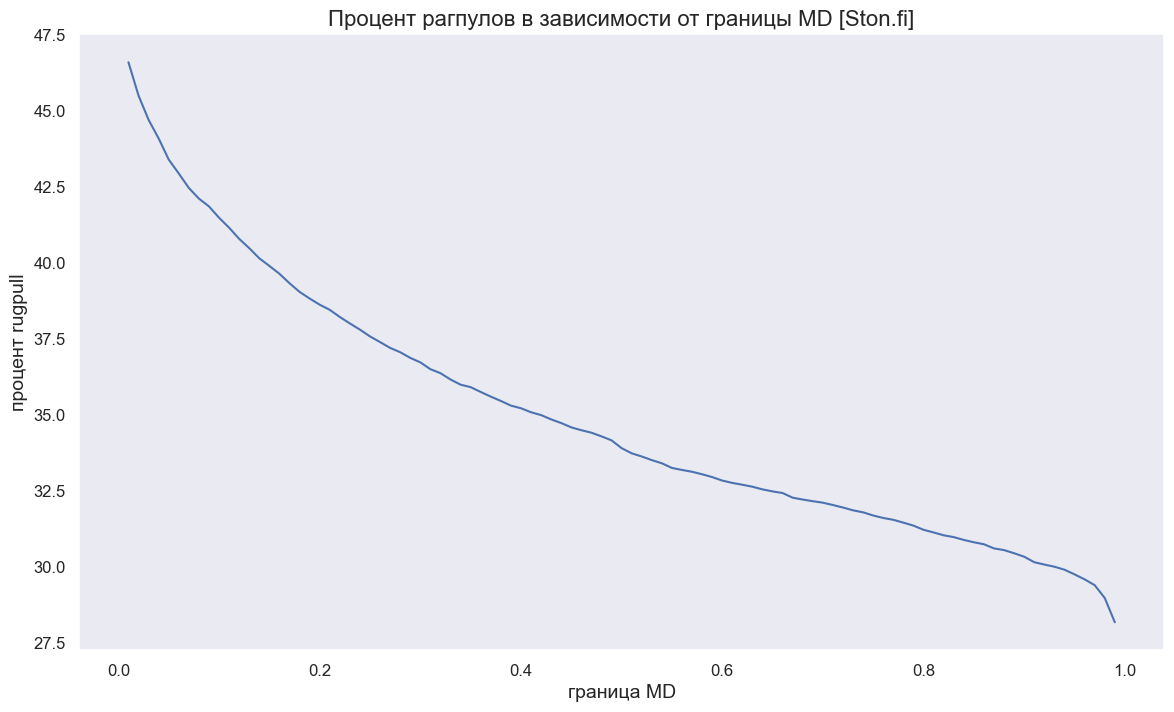

In [18]:
min_md = 1
max_md = 100
plt.plot([i/100 for i in range(min_md,max_md)], [(((stonfi_df['max_tvl_60min'] - stonfi_df['min_tvl_t_to_60min']) / stonfi_df['max_tvl_60min'] > i / 100).astype(int)).mean()*100 for i in range(min_md,max_md)])
plt.grid()
plt.xlabel('граница MD')
plt.ylabel('процент rugpull')
plt.title("Процент рагпулов в зависимости от границы MD [Ston.fi]")
plt.show()

In [19]:
# определяем таргет
# stonfi_df['target'] = stonfi_df['alice_rugpull_180min']
stonfi_df['tvl_target_10min'] = ((stonfi_df['max_tvl_10min'] -   stonfi_df['min_tvl_t_to_10min']) / stonfi_df['max_tvl_10min'] > 0.99).astype(int)
stonfi_df['tvl_target_30min'] = ((stonfi_df['max_tvl_30min'] -   stonfi_df['min_tvl_t_to_30min']) / stonfi_df['max_tvl_30min'] > 0.99).astype(int)
stonfi_df['tvl_target_60min'] = ((stonfi_df['max_tvl_60min'] -   stonfi_df['min_tvl_t_to_60min']) / stonfi_df['max_tvl_60min'] > 0.99).astype(int)
stonfi_df['tvl_target_120min'] = ((stonfi_df['max_tvl_120min'] - stonfi_df['min_tvl_t_to_120min']) / stonfi_df['max_tvl_120min'] > 0.99).astype(int)
stonfi_df['tvl_target_180min'] = ((stonfi_df['max_tvl_180min'] - stonfi_df['min_tvl_t_to_180min']) / stonfi_df['max_tvl_180min'] > 0.99).astype(int)
stonfi_df['tvl_target_240min'] = ((stonfi_df['max_tvl_240min'] - stonfi_df['min_tvl_t_to_240min']) / stonfi_df['max_tvl_240min'] > 0.99).astype(int)
stonfi_df['tvl_target_300min'] = ((stonfi_df['max_tvl_300min'] - stonfi_df['min_tvl_t_to_300min']) / stonfi_df['max_tvl_300min'] > 0.99).astype(int)
stonfi_df['tvl_target_360min'] = ((stonfi_df['max_tvl_360min'] - stonfi_df['min_tvl_t_to_360min']) / stonfi_df['max_tvl_360min'] > 0.99).astype(int)
stonfi_df['tvl_target_420min'] = ((stonfi_df['max_tvl_420min'] - stonfi_df['min_tvl_t_to_420min']) / stonfi_df['max_tvl_420min'] > 0.99).astype(int)
# stonfi_df = stonfi_df.drop(['max_tvl_10min', 'max_tvl_30min', 'max_tvl_60min', 'max_tvl_120min', 'max_tvl_180min', 'max_tvl_240min', 'max_tvl_300min', 'max_tvl_360min', 'max_tvl_420min', 'min_tvl_t_to_10min', 'min_tvl_t_to_30min', 'min_tvl_t_to_60min', 'min_tvl_t_to_120min', 'min_tvl_t_to_180min', 'min_tvl_t_to_240min', 'min_tvl_t_to_300min', 'min_tvl_t_to_360min', 'min_tvl_t_to_420min'], axis=1) 
print(f"tvl_target_60min = {float(stonfi_df['tvl_target_60min'].sum()/len(stonfi_df)) * 100:.3}% rugpulls")
print(f'len of stonfi_df: {len(stonfi_df)}')

tvl_target_60min = 28.2% rugpulls
len of stonfi_df: 18283


### Alice VS TVL

In [20]:
import pandas as pd
import numpy as np
from scipy.stats import chi2_contingency

# Предполагается, что у вас есть DataFrame с колонками Alice и TVL
# Например:
# df = pd.DataFrame({'Alice': [1, 0, 1, 0, 1], 'TVL': [0, 1, 1, 0, 1]})

# Строим таблицу сопряженности (contingency table)
contingency_table = pd.crosstab(stonfi_df['alice_rugpull_60min'], stonfi_df['tvl_target_60min'])

# Функция для вычисления phi-коэффициента
def phi_coef(contingency_table):
    chi2, p, _, _ = chi2_contingency(contingency_table)
    n = contingency_table.sum().sum()
    return np.sqrt(chi2 / n)

phi = phi_coef(contingency_table)
print(f"Phi-коэффициент корреляции между Alice и TVL: {phi:.4f}")

# Если нужен p-value (значимость корреляции)
chi2, p, dof, expected = chi2_contingency(contingency_table)
print(f"p-value: {p:.4f}")
contingency_table

Phi-коэффициент корреляции между Alice и TVL: 0.2456
p-value: 0.0000


tvl_target_60min,0,1
alice_rugpull_60min,,
0,3621,269
1,9509,4884


In [21]:
display(stonfi_df.describe(include='all'))

,token_address,project,pool_address,version,jetton_deployment_at,jetton_first_tx_sender,symbol,decimals,buy_price_std_5min,buys_cnt,...,min_pool_info_time_ts,tvl_target_10min,tvl_target_30min,tvl_target_60min,tvl_target_120min,tvl_target_180min,tvl_target_240min,tvl_target_300min,tvl_target_360min,tvl_target_420min
count,18283,18283,18283,18283.000000,18283,18283,18186,17782.000000,1.081900e+04,18283.000000,...,1.828300e+04,18283.000000,18283.000000,18283.000000,18283.000000,18283.000000,18283.000000,18283.000000,18283.000000,18283.000000
unique,18122,1,18283,NaN,NaN,12009,12219,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
top,0:2F956143C461769579BAEF2E32CC2D7BC18283F40D20...,ston.fi,0:033754612381ECB378DBA8D3BDEAC41DECB116A12DAC...,NaN,NaN,0:BDDF242D6C6B565AFC04AE709586257A511304D75A8E...,USDT,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
freq,5,18283,1,NaN,NaN,666,101,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
mean,NaN,NaN,NaN,1.243942,2024-07-04 01:28:40.411037696+00:00,NaN,NaN,8.583230,2.284930e+07,403.209430,...,1.720550e+09,0.093967,0.217798,0.281847,0.322321,0.337581,0.345786,0.351529,0.355904,0.360007
min,NaN,NaN,NaN,1.000000,2022-06-05 21:18:30+00:00,NaN,NaN,0.000000,0.000000e+00,1.000000,...,1.704317e+09,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,NaN,NaN,NaN,1.000000,2024-04-10 20:27:02.500000+00:00,NaN,NaN,9.000000,9.227526e-08,2.000000,...,1.712974e+09,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,NaN,NaN,NaN,1.000000,2024-05-30 20:50:16+00:00,NaN,NaN,9.000000,4.468880e-06,5.000000,...,1.717425e+09,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
75%,NaN,NaN,NaN,1.000000,2024-09-15 16:54:38.500000+00:00,NaN,NaN,9.000000,3.806698e+00,17.000000,...,1.727413e+09,0.000000,0.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000
max,NaN,NaN,NaN,2.000000,2025-03-31 20:33:15+00:00,NaN,NaN,33.000000,4.478343e+10,535373.000000,...,1.747672e+09,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


## Dataset prepare

In [22]:
stonfi_df['count_tx_5min'] = stonfi_df['buys_5min'] + stonfi_df['sells_5min']
stonfi_df['buy_perc_5min'] = stonfi_df['buys_5min']/stonfi_df['count_tx_5min']
stonfi_df['sell_perc_5min'] = stonfi_df['sells_5min']/stonfi_df['count_tx_5min']
stonfi_df['total_usd_volume_5min'] = stonfi_df['total_usd_buy_volume_5min'] + stonfi_df['total_usd_sell_volume_5min']
for col in ['pool_deployment_at', 'jetton_deployment_at']:
    stonfi_df[f'{col}_month'] = pd.to_datetime(stonfi_df[col]).dt.month
stonfi_df['jetton_creation_year'] = pd.to_datetime(stonfi_df['jetton_deployment_at']).dt.year
stonfi_df['jetton_creation_trade_delta'] = (stonfi_df['first_trade_time'] - stonfi_df['jetton_deployment_at']).dt.seconds
stonfi_df['pool_creation_trade_delta'] = (stonfi_df['first_trade_time'] - stonfi_df['pool_deployment_at']).dt.seconds
stonfi_df['is_pool_creator'] = (stonfi_df['pool_first_tx_sender'] == stonfi_df['jetton_first_tx_sender']).astype(int)

stonfi_df['buy_sell_ratio'] = stonfi_df['buys_5min'] / (stonfi_df['sells_5min'] + 1e-6)
stonfi_df['price_range'] = stonfi_df['price_max_5min'] - stonfi_df['price_min_5min']
stonfi_df['price_delta_5min'] = stonfi_df['price_5min'] - stonfi_df['initial_price']

In [23]:
print(f"{'column_name':27}, {'example':24}, {'null percent'}, is > 0")
for feature in all_features:
    print(f"{feature:28}= {stonfi_df.iloc[0][feature]:24}, {stonfi_df[feature].isna().mean()*100:11.3}%, {(stonfi_df[feature] > 0).all()}")

column_name                , example                 , null percent, is > 0
buy_sell_ratio              =       2.9999970000030003,         0.0%, False
price_range                 =   1.3948569725604233e-10,         0.0%, False
buys_5min                   =                        3,         0.0%, False
sells_5min                  =                        1,         0.0%, False
buy_perc_5min               =                     0.75,         0.0%, False
sell_perc_5min              =                     0.25,         0.0%, False
unique_buyers_5min          =                        3,         0.0%, False
unique_sellers_5min         =                        1,         0.0%, False
total_usd_volume_5min       =                54.374534,         0.0%, True
total_usd_buy_volume_5min   =                43.139776,         0.0%, False
total_usd_sell_volume_5min  =                11.234758,         0.0%, False
decimals                    =                      9.0,        2.74%, False
avg_5min_lp_f

## Data distribution

In [ ]:
stonfi_df['target'] = stonfi_df['alice_rugpull_60min']

In [ ]:
# import pandas as pd
# import numpy as np
# import seaborn as sns
# import matplotlib.pyplot as plt
# from scipy.stats import pointbiserialr, chi2_contingency
# from statsmodels.stats.contingency_tables import Table

# def cramers_v(x, y):
#     """Вычисление корреляции Крамера для категориальных признаков"""
#     confusion_matrix = pd.crosstab(x, y)
#     chi2 = chi2_contingency(confusion_matrix)[0]
#     n = confusion_matrix.sum().sum()
#     phi2 = chi2/n
#     r, k = confusion_matrix.shape
#     return np.sqrt(phi2 / min(k-1, r-1))

# # Анализ для числовых признаков
# numeric_features = stonfi_df[numerical_features + cyclical_features].select_dtypes(include=np.number).columns.tolist()
# # numeric_features.remove('target')  # Исключаем целевую переменную

# numeric_correlations = []
# for feature in numeric_features:
#     r, p = pointbiserialr(stonfi_df[feature], stonfi_df['target'])
#     numeric_correlations.append({
#         'feature': feature,
#         'correlation': r,
#         'p-value': p
#     })
    
# numeric_corr_df = pd.DataFrame(numeric_correlations).sort_values(
#     by='correlation', key=abs, ascending=False)

# # Анализ для категориальных признаков
# categorical_features = stonfi_df.select_dtypes(include=['object', 'category']).columns.tolist()

# categorical_correlations = []
# for feature in categorical_features:
#     v = cramers_v(stonfi_df[feature], stonfi_df['target'])
#     categorical_correlations.append({
#         'feature': feature,
#         'cramers_v': v
#     })
    
# categorical_corr_df = pd.DataFrame(categorical_correlations).sort_values(
#     by='cramers_v', ascending=False)

# # Визуализация результатов
# plt.figure(figsize=(12, 6))
# sns.barplot(
#     x='correlation', 
#     y='feature', 
#     data=numeric_corr_df.head(10),
#     palette='coolwarm'
# )
# plt.title('Топ-10 числовых признаков по корреляции с целевой переменной')
# plt.xlabel('Точечно-бисериальная корреляция')
# plt.ylabel('Признак')
# plt.show()

# # Вывод результатов
# print("Топ числовых признаков:")
# print(numeric_corr_df.head(10).to_string(index=False))

# print("\nТоп категориальных признаков:")
# print(categorical_corr_df.head(10).to_string(index=False))

# # Пример визуализации распределения для топ-признака
# top_n = 5
# for i in range(top_n):
#     top_feature = numeric_corr_df.iloc[i]['feature']
#     plt.figure(figsize=(10, 6))
#     sns.boxplot(x='target', y=top_feature, data=stonfi_df)
#     plt.title(f'Распределение {top_feature} по классам')
#     plt.xlabel('Целевой класс')
#     plt.ylabel(top_feature)
#     plt.show()


### Zeros

In [ ]:
plot_zeros_count_and_percentage(stonfi_df[all_features])
plot_nulls_count_and_percentage(stonfi_df[all_features])

### Alice

In [ ]:
stonfi_df['target'] = stonfi_df['alice_rugpull_60min']
plot_features(stonfi_df, all_features)

### TVL

In [ ]:
stonfi_df['target'] = stonfi_df['tvl_target_60min']
plot_features(stonfi_df, all_features)

# Dedust

## Dataset load

In [24]:
dedust_df = pd.read_csv('datasets/dedust_dataset.csv')

dedust_df['first_buy_time'] = pd.to_datetime(dedust_df['first_buy_time'])
dedust_df['first_sell_time'] = pd.to_datetime(dedust_df['first_sell_time'])
dedust_df['pool_deployment_at'] = pd.to_datetime(dedust_df['pool_deployment_at'])
dedust_df['jetton_deployment_at'] = pd.to_datetime(dedust_df['jetton_deployment_at'])
dedust_df['min_pool_info_time'] = pd.to_datetime(dedust_df['min_pool_info_time'])

dedust_df['first_trade_time'] = dedust_df[['first_buy_time','first_sell_time']].apply(lambda x: min(x), axis=1)
dedust_df.loc[(dedust_df['first_sell_time'] - dedust_df['first_trade_time']).dt.seconds >= 5*60, 'first_sell_time'] = None
dedust_df.loc[(dedust_df['first_buy_time'] - dedust_df['first_trade_time']).dt.seconds >= 5*60, 'first_buy_time'] = None

dedust_df['first_buy_time_ts'] = dedust_df['first_buy_time'].astype(np.int64) // 10**9
dedust_df['first_sell_time_ts'] = dedust_df['first_sell_time'].astype(np.int64) // 10**9
dedust_df['pool_deployment_at_ts'] = dedust_df['pool_deployment_at'].astype(np.int64) // 10**9
dedust_df['jetton_deployment_at_ts'] = dedust_df['jetton_deployment_at'].astype(np.int64) // 10**9
dedust_df['min_pool_info_time_ts'] = dedust_df['min_pool_info_time'].astype(np.int64) // 10**9

dedust_df.loc[dedust_df['first_buy_time_ts'] < 0, 'first_buy_time_ts'] = None
dedust_df.loc[dedust_df['first_sell_time_ts'] < 0, 'first_sell_time_ts'] = None
dedust_df.loc[dedust_df['pool_deployment_at_ts'] < 0, 'pool_deployment_at_ts'] = None
dedust_df.loc[dedust_df['jetton_deployment_at_ts'] < 0, 'jetton_deployment_at_ts'] = None
dedust_df.loc[dedust_df['min_pool_info_time_ts'] < 0, 'min_pool_info_time_ts'] = None
print(f'len of dedust_df: {len(dedust_df)}')
# dedust_df.head()

len of dedust_df: 33087


## Drop some tokens

In [25]:
# дропаем токены без данных
print(f'len of dedust_df: {len(dedust_df)}')
dedust_df = dedust_df[dedust_df[['first_buy_time','first_sell_time']].apply(lambda x: min(x), axis=1).isna() == False]
print(f'len of dedust_df after drop: {len(dedust_df)}')
dedust_df = dedust_df[dedust_df['max_tvl_5min'].isna() == False]
print(f'len of dedust_df after drop: {len(dedust_df)}')

len of dedust_df: 33087
len of dedust_df after drop: 32866
len of dedust_df after drop: 30097


## Rug

### Idle

In [26]:
x = ['10 min','30 min','60 min','120 min','180 min','240 min','300 min','360 min','420 min']
dedust_idle_y = [dedust_df['alice_rugpull_' + i.replace(' ', '')].mean() for i in x]
print('Alice approach [Dedust]')
pd.DataFrame(np.array([x,dedust_idle_y]).T, columns=['time interval for rug', 'percent for rug'])

Alice approach [Dedust]


,time interval for rug,percent for rug
0,10 min,0.3827291756653487
1,30 min,0.6596006246469748
2,60 min,0.8044655613516297
3,120 min,0.8937435624813105
4,180 min,0.9200252516862145
5,240 min,0.934544971259594
6,300 min,0.9440475794929727
7,360 min,0.9506263082699272
8,420 min,0.9562747117652922


### TVL

In [27]:
x = ['10 min','30 min','60 min','120 min','180 min','240 min','300 min','360 min','420 min']
dedust_tvl_y = [((dedust_df['max_tvl_' + i.replace(' ','')] - dedust_df['min_tvl_t_to_' + i.replace(' ','')]) / dedust_df['max_tvl_' + i.replace(' ','')] > 0.99).astype(int).mean() for i in x]
print('TVL approach [Dedust]')
pd.DataFrame(np.array([x,dedust_tvl_y]).T, columns=['time interval for rug', 'percent for rug'])

TVL approach [Dedust]


,time interval for rug,percent for rug
0,10 min,0.2177957936006911
1,30 min,0.45678971326045786
2,60 min,0.5695252018473602
3,120 min,0.6399973419277669
4,180 min,0.6657141907831345
5,240 min,0.6814632687643287
6,300 min,0.6906336179685683
7,360 min,0.6983420274445958
8,420 min,0.7064491477555903


### график

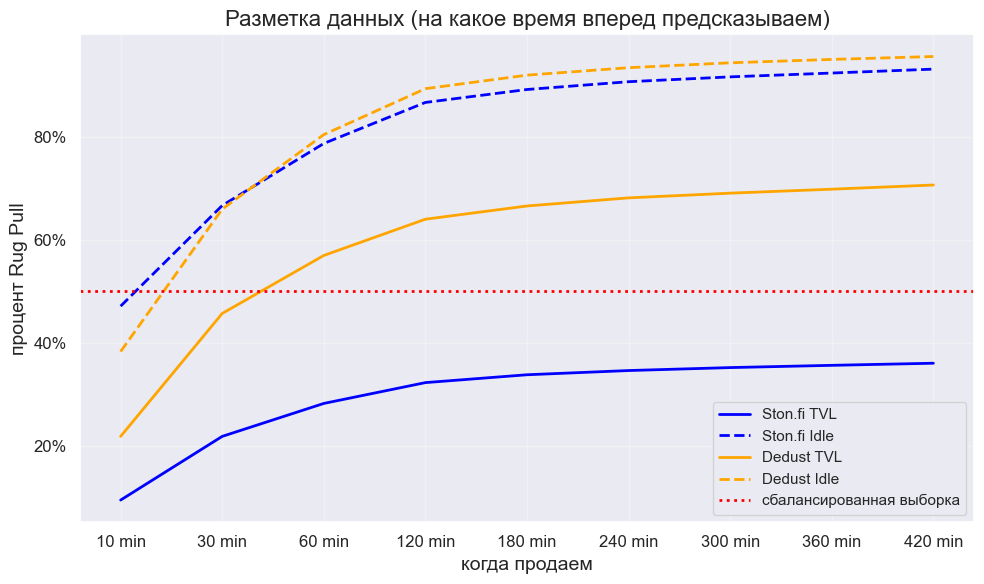

In [28]:
plt.figure(figsize=(10, 6))

plt.plot(x, stonfi_tvl_y, label='Ston.fi TVL', color='blue', linewidth=2)
plt.plot(x, stonfi_idle_y, label='Ston.fi Idle', color='blue', linestyle='--', linewidth=2)
plt.plot(x, dedust_tvl_y, label='Dedust TVL', color='orange', linewidth=2)
plt.plot(x, dedust_idle_y, label='Dedust Idle', color='orange', linestyle='--', linewidth=2)
plt.axhline(0.5, color='red', linestyle=':', linewidth=2, label='сбалансированная выборка')

plt.gca().yaxis.set_major_formatter(PercentFormatter(1))
plt.title('Разметка данных (на какое время вперед предсказываем)')
plt.xlabel('когда продаем')
plt.ylabel('процент Rug Pull')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [29]:
dedust_df.describe(include='all')

,token_address,project,pool_address,jetton_deployment_at,jetton_first_tx_sender,symbol,decimals,buy_price_std_5min,buys_cnt,buys_5min,...,min_tvl_t_to_360min,tvl_420min,max_tvl_420min,min_tvl_t_to_420min,first_trade_time,first_buy_time_ts,first_sell_time_ts,pool_deployment_at_ts,jetton_deployment_at_ts,min_pool_info_time_ts
count,30097,30097,30097,30097,30097,30080,29088.000000,2.322100e+04,30097.000000,30097.000000,...,3.009700e+04,3.009700e+04,3.009700e+04,3.009700e+04,30097,3.009700e+04,7.863000e+03,3.009700e+04,3.009700e+04,3.009700e+04
unique,30096,1,30097,NaN,18591,18517,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
top,0:CF76AF318C0872B58A9F1925FC29C156211782B9FB01...,dedust,0:2F042E4B2A20B253FD9F89B067DFE546978D19FA95B0...,NaN,0:8FB0E09015CF908387BF247738659BCEFA8B05802AD3...,ICE,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
freq,2,30097,1,NaN,288,107,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
mean,NaN,NaN,NaN,2024-06-05 18:35:42.655547392+00:00,NaN,NaN,8.803974,1.569767e+06,154.242416,5.770010,...,1.767880e+03,2.223553e+03,6.187124e+03,1.725003e+03,2024-06-07 11:01:13.777054208+00:00,1.717758e+09,1.718386e+09,1.717733e+09,1.717613e+09,1.717734e+09
min,NaN,NaN,NaN,2022-07-08 15:14:47+00:00,NaN,NaN,0.000000,0.000000e+00,1.000000,1.000000,...,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,2024-01-01 07:56:54+00:00,1.704096e+09,1.704096e+09,1.704096e+09,1.657293e+09,1.704096e+09
25%,NaN,NaN,NaN,2024-04-25 22:11:25+00:00,NaN,NaN,9.000000,1.674502e-08,3.000000,2.000000,...,0.000000e+00,0.000000e+00,4.381147e+02,0.000000e+00,2024-04-27 09:05:33+00:00,1.714209e+09,1.715256e+09,1.714154e+09,1.714083e+09,1.714155e+09
50%,NaN,NaN,NaN,2024-06-11 16:54:04+00:00,NaN,NaN,9.000000,5.294752e-07,6.000000,3.000000,...,0.000000e+00,1.433120e-01,1.574152e+03,0.000000e+00,2024-06-12 14:22:16+00:00,1.718202e+09,1.719565e+09,1.718195e+09,1.718125e+09,1.718195e+09
75%,NaN,NaN,NaN,2024-07-10 05:59:39+00:00,NaN,NaN,9.000000,2.917208e-05,17.000000,6.000000,...,7.149677e+00,6.901027e+00,4.041707e+03,4.106453e+00,2024-07-10 14:50:49+00:00,1.720623e+09,1.720743e+09,1.720619e+09,1.720591e+09,1.720619e+09
max,NaN,NaN,NaN,2025-03-29 14:13:37+00:00,NaN,NaN,32.000000,1.980751e+10,898258.000000,640.000000,...,3.009844e+06,3.447739e+06,4.365947e+06,3.009844e+06,2025-03-29 15:06:35+00:00,1.743261e+09,1.743261e+09,1.743259e+09,1.743258e+09,1.743261e+09


## Define target

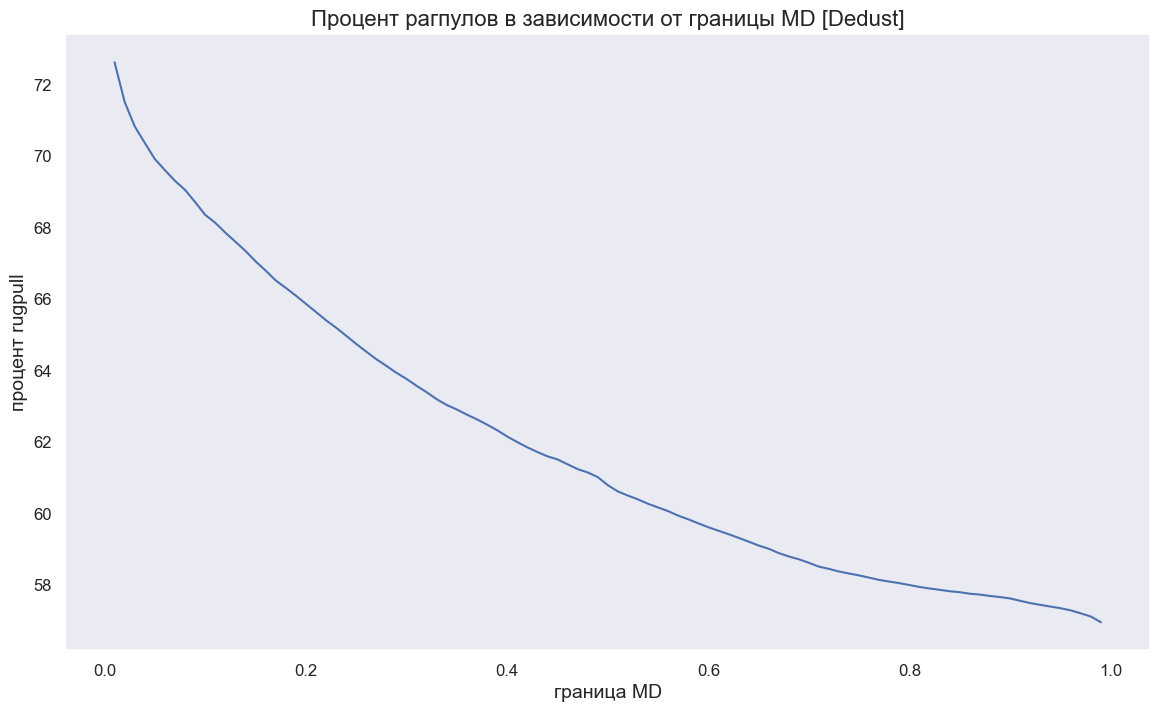

In [30]:
plt.plot([i/100 for i in range(1,100)], [(((dedust_df['max_tvl_60min'] - dedust_df['min_tvl_t_to_60min']) / dedust_df['max_tvl_60min'] > i / 100).astype(int)).mean()*100 for i in range(1,100)])
plt.grid()
plt.title('Процент рагпулов в зависимости от границы MD [Dedust]')
plt.xlabel('граница MD')
plt.ylabel('процент rugpull')
plt.show()

In [31]:
# определяем таргет
# dedust_df['target'] = dedust_df['alice_rugpull_180min']
dedust_df['tvl_target_10min'] = ((dedust_df['max_tvl_10min'] -   dedust_df['min_tvl_t_to_10min']) / dedust_df['max_tvl_10min'] > 0.99).astype(int)
dedust_df['tvl_target_30min'] = ((dedust_df['max_tvl_30min'] -   dedust_df['min_tvl_t_to_30min']) / dedust_df['max_tvl_30min'] > 0.99).astype(int)
dedust_df['tvl_target_60min'] = ((dedust_df['max_tvl_60min'] -   dedust_df['min_tvl_t_to_60min']) / dedust_df['max_tvl_60min'] > 0.99).astype(int)
dedust_df['tvl_target_120min'] = ((dedust_df['max_tvl_120min'] - dedust_df['min_tvl_t_to_120min']) / dedust_df['max_tvl_120min'] > 0.99).astype(int)
dedust_df['tvl_target_180min'] = ((dedust_df['max_tvl_180min'] - dedust_df['min_tvl_t_to_180min']) / dedust_df['max_tvl_180min'] > 0.99).astype(int)
dedust_df['tvl_target_240min'] = ((dedust_df['max_tvl_240min'] - dedust_df['min_tvl_t_to_240min']) / dedust_df['max_tvl_240min'] > 0.99).astype(int)
dedust_df['tvl_target_300min'] = ((dedust_df['max_tvl_300min'] - dedust_df['min_tvl_t_to_300min']) / dedust_df['max_tvl_300min'] > 0.99).astype(int)
dedust_df['tvl_target_360min'] = ((dedust_df['max_tvl_360min'] - dedust_df['min_tvl_t_to_360min']) / dedust_df['max_tvl_360min'] > 0.99).astype(int)
dedust_df['tvl_target_420min'] = ((dedust_df['max_tvl_420min'] - dedust_df['min_tvl_t_to_420min']) / dedust_df['max_tvl_420min'] > 0.99).astype(int)
# dedust_df = dedust_df.drop(['max_tvl_10min', 'max_tvl_30min', 'max_tvl_60min', 'max_tvl_120min', 'max_tvl_180min', 'max_tvl_240min', 'max_tvl_300min', 'max_tvl_360min', 'max_tvl_420min', 'min_tvl_t_to_10min', 'min_tvl_t_to_30min', 'min_tvl_t_to_60min', 'min_tvl_t_to_120min', 'min_tvl_t_to_180min', 'min_tvl_t_to_240min', 'min_tvl_t_to_300min', 'min_tvl_t_to_360min', 'min_tvl_t_to_420min'], axis=1) 
print(f"tvl_target_60min = {float(dedust_df['tvl_target_60min'].sum()/len(dedust_df)) * 100:.3}% rugpulls")
print(f'len of dedust_df: {len(dedust_df)}')

tvl_target_60min = 57.0% rugpulls
len of dedust_df: 30097


## Dataset prepare

In [32]:
dedust_df['first_trade_time'] = dedust_df[['first_buy_time','first_sell_time']].apply(lambda x: min(x), axis=1)
dedust_df['count_tx_5min'] = dedust_df['buys_5min'] + dedust_df['sells_5min']
dedust_df['buy_perc_5min'] = dedust_df['buys_5min']/dedust_df['count_tx_5min']
dedust_df['sell_perc_5min'] = dedust_df['sells_5min']/dedust_df['count_tx_5min']
dedust_df['total_usd_volume_5min'] = dedust_df['total_usd_buy_volume_5min'] + dedust_df['total_usd_sell_volume_5min']
for col in ['pool_deployment_at', 'jetton_deployment_at']:
    dedust_df[f'{col}_month'] = pd.to_datetime(dedust_df[col]).dt.month
dedust_df['jetton_creation_year'] = pd.to_datetime(dedust_df['jetton_deployment_at']).dt.year
dedust_df['jetton_creation_trade_delta'] = (dedust_df['first_trade_time'] - dedust_df['jetton_deployment_at']).dt.seconds
dedust_df['pool_creation_trade_delta'] = (dedust_df['first_trade_time'] - dedust_df['pool_deployment_at']).dt.seconds
dedust_df['is_pool_creator'] = (dedust_df['pool_first_tx_sender'] == dedust_df['jetton_first_tx_sender']).astype(int)

dedust_df['buy_sell_ratio'] = dedust_df['buys_5min'] / (dedust_df['sells_5min'] + 1e-6)
dedust_df['price_range'] = dedust_df['price_max_5min'] - dedust_df['price_min_5min']
dedust_df['price_delta_5min'] = dedust_df['price_5min'] - dedust_df['initial_price']

## Data distribution

In [24]:
dedust_df['target'] = dedust_df['alice_rugpull_60min']

In [ ]:

# def cramers_v(x, y):
#     """Вычисление корреляции Крамера для категориальных признаков"""
#     confusion_matrix = pd.crosstab(x, y)
#     chi2 = chi2_contingency(confusion_matrix)[0]
#     n = confusion_matrix.sum().sum()
#     phi2 = chi2/n
#     r, k = confusion_matrix.shape
#     return np.sqrt(phi2 / min(k-1, r-1))

# # Анализ для числовых признаков
# numeric_features = dedust_df[numerical_features + cyclical_features].select_dtypes(include=np.number).columns.tolist()
# # numeric_features.remove('target')  # Исключаем целевую переменную

# numeric_correlations = []
# for feature in numeric_features:
#     r, p = pointbiserialr(dedust_df[feature], dedust_df['target'])
#     numeric_correlations.append({
#         'feature': feature,
#         'correlation': r,
#         'p-value': p
#     })
    
# numeric_corr_df = pd.DataFrame(numeric_correlations).sort_values(
#     by='correlation', key=abs, ascending=False)

# # Анализ для категориальных признаков
# categorical_features = dedust_df.select_dtypes(include=['object', 'category']).columns.tolist()

# categorical_correlations = []
# for feature in categorical_features:
#     v = cramers_v(dedust_df[feature], dedust_df['target'])
#     categorical_correlations.append({
#         'feature': feature,
#         'cramers_v': v
#     })
    
# categorical_corr_df = pd.DataFrame(categorical_correlations).sort_values(
#     by='cramers_v', ascending=False)

# # Визуализация результатов
# plt.figure(figsize=(12, 6))
# sns.barplot(
#     x='correlation', 
#     y='feature', 
#     data=numeric_corr_df.head(10),
#     palette='coolwarm'
# )
# plt.title('Топ-10 числовых признаков по корреляции с целевой переменной')
# plt.xlabel('Точечно-бисериальная корреляция')
# plt.ylabel('Признак')
# plt.show()

# # Вывод результатов
# print("Топ числовых признаков:")
# print(numeric_corr_df.head(10).to_string(index=False))

# print("\nТоп категориальных признаков:")
# print(categorical_corr_df.head(10).to_string(index=False))

# # Пример визуализации распределения для топ-признака
# top_n = 5
# for i in range(top_n):
#     top_feature = numeric_corr_df.iloc[i]['feature']
#     plt.figure(figsize=(10, 6))
#     sns.boxplot(x='target', y=top_feature, data=dedust_df)
#     plt.title(f'Распределение {top_feature} по классам')
#     plt.xlabel('Целевой класс')
#     plt.ylabel(top_feature)
#     plt.show()


### Zeros

In [ ]:
plot_zeros_count_and_percentage(dedust_df[all_features])
plot_nulls_count_and_percentage(dedust_df[all_features])

### Alice

In [ ]:
dedust_df['target'] = dedust_df['alice_rugpull_60min']
plot_features(dedust_df, all_features)

### TVL

In [ ]:
dedust_df['target'] = dedust_df['tvl_target_60min']
plot_features(dedust_df, all_features)

### Dedust Ston.fi comparation

In [ ]:
plot_dedust_vs_stonfi(stonfi_df, dedust_df)

# Learn

In [ ]:

# Функции для циклического кодирования
def sin_transformer(period):
    return FunctionTransformer(lambda x: np.sin(x / period * 2 * np.pi), feature_names_out= lambda x, y: y)

def cos_transformer(period):
    return FunctionTransformer(lambda x: np.cos(x / period * 2 * np.pi), feature_names_out= lambda x, y: y)

## Data prepare

In [ ]:
dedust_df['target'] = dedust_df['tvl_target_60min']
stonfi_df['target'] = stonfi_df['tvl_target_60min']

In [ ]:
# Разделение данных
all_features = numerical_features + time_features
X = dedust_df[all_features]
y = dedust_df['target']
# X = stonfi_df[all_features]
# y = stonfi_df['target']
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

In [ ]:
# Конвейер предобработки
numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', 'passthrough')  # Заглушка для GridSearchCV
])

time_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', 'passthrough')  # Заглушка для GridSearchCV
])

preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numerical_features),
        ('time', time_transformer, time_features),
    ]
)

preprocessor

## learn

In [ ]:
# Настройка моделей и гиперпараметров
common_preproc_params = {
    'preprocessor__num__scaler': [
        None,  # Без масштабирования
        StandardScaler(),
        # MaxAbsScaler(),
        # PowerTransformer(method='yeo-johnson')
    ],
    'preprocessor__time__scaler': [
        None,  # Без масштабирования
        StandardScaler(),
        # MaxAbsScaler(),
        # PowerTransformer(method='yeo-johnson')
    ]
}

neg_class_perc = (y_train == 0).mean()
pos_class_perc = 1 - neg_class_perc

models_config = {
    'RandomForest': {
        'model': RandomForestClassifier(random_state=42, n_jobs=-1, bootstrap=True),
        'params': {
            **common_preproc_params,
            'classifier__n_estimators': [200, 300],
            'classifier__max_depth': [None, 15, 20],
            'classifier__min_samples_split': [2, 5],
            'classifier__max_features': ['sqrt', 0.8],
            'classifier__class_weight': [{0: neg_class_perc, 1: pos_class_perc}, 'balanced']
        }
    },
    'GradientBoosting': {
        'model': GradientBoostingClassifier(random_state=42),
        'params': {
            **common_preproc_params,
            'classifier__learning_rate': [0.05, 0.1],
            'classifier__n_estimators': [200, 300],
            'classifier__max_depth': [3, 5, 10],
            'classifier__min_samples_split': [2, 5],
            'classifier__max_features': ['sqrt', 0.8],
            'classifier__subsample': [0.8, 1.0],
            'classifier__loss': ['log_loss', 'exponential']
        }
    },
    'AdaBoost': {
        'model': AdaBoostClassifier(random_state=42),
        'params': {
            'classifier__n_estimators': [100, 200],
            'classifier__learning_rate': [0.01, 0.5, 1.0]
        }
    },
    'DecisionTree': {
        'model': DecisionTreeClassifier(class_weight='balanced', random_state=42),
        'params': {
            **common_preproc_params,
            'classifier__max_depth': [None, 5, 10, 15, 20],
            'classifier__min_samples_split': [2, 5],
            'classifier__max_features': ['sqrt', 0.8]
        }
    },
    'ExtremeGradientBoosting': {
        'model': XGBClassifier(
            objective='binary:logistic',
            eval_metric='logloss',
            random_state=42,
            n_jobs=-1
        ),
        'params': {
            **common_preproc_params,
            'classifier__learning_rate': [0.05, 0.1],
            'classifier__max_depth': [5, 7, 10],
            'classifier__subsample': [0.8, 1.0],
            'classifier__colsample_bytree': [0.8, 1.0],
            'classifier__gamma': [0, 1, 5],
            'classifier__scale_pos_weight': [pos_class_perc/neg_class_perc, 0.83, neg_class_perc/pos_class_perc],
            'classifier__reg_alpha': [0, 0.1, 1],
            'classifier__reg_lambda': [1, 1.5, 2]
        }
    }
}

# Обучение и оптимизация
results = {}
for model_name, config in models_config.items():
    print(f"Fit {model_name}")
    pipeline = Pipeline(steps=[
        ('preprocessor', preprocessor),
        ('classifier', config['model'])
    ])
    
    grid_search = GridSearchCV(
        estimator=pipeline,
        param_grid=config['params'],
        scoring='roc_auc',
        cv=StratifiedKFold(n_splits=3),
        n_jobs=-1,
        verbose=1
    )
    
    grid_search.fit(X_train, y_train)
    
    best_model = grid_search.best_estimator_
    y_pred = best_model.predict(X_test)
    y_proba = best_model.predict_proba(X_test)[:, 1]
    
    results[model_name] = {
        'best_params': grid_search.best_params_,
        'best_score': grid_search.best_score_,
        'test_auc': roc_auc_score(y_test, y_proba),
        'report': classification_report(y_test, y_pred),
        'model': best_model
    }

## Анализ результатов

In [ ]:

# Анализ результатов
for model_name, metrics in results.items():
    print(f"Model: {model_name}")
    print(f"Best CV AUC: {metrics['best_score']:.4f}")
    print(f"Test AUC: {metrics['test_auc']:.4f}")
    print("Best Parameters:")
    for param, value in metrics['best_params'].items():
        print(f"  {param}: {value}")
    print("Classification Report:")
    print(metrics['report'])
    print("\n" + "="*80 + "\n")

# Визуализация лучшей модели
best_model_name = max(results, key=lambda x: results[x]['test_auc'])
print(F"BEST MODEL WITH {max([results[x]['test_auc'] for x in results]):.3} AUC IS {best_model_name}")

In [ ]:
plt.figure(figsize=(10, 6))
for name, res in results.items():
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))
    # confusion_matrix
    cm = confusion_matrix(y_test, res['model'].predict(X_test))
    disp = ConfusionMatrixDisplay(confusion_matrix=cm)
    disp.plot(cmap='Blues', ax=ax1)
    ax1.set_title(f'Model: {name}')
    # График Precision Recall
    PrecisionRecallDisplay.from_estimator(
        res['model'], X_test, y_test, name=name, ax=ax2
    )
    ax2.set_title('Precision-Recall Curve Comparison')
    plt.show()

    # importances фичей
    importances = res['model'].named_steps['classifier'].feature_importances_
    # feature_names = numerical_features + categorical_features + cyclical_features + cyclical_features
    feature_names = numerical_features + time_features

    plt.figure(figsize=(12, 8))
    pd.Series(importances, index=feature_names).nlargest(len(feature_names)).plot(kind='barh')
    plt.title(f'Feature Importance - {name}')
    plt.show()


In [ ]:
pd.Series(importances, index=feature_names)

In [ ]:
stonfi_df['target'].mean()

# [Idle] Обучение на объединенном датасете

## Data prepare

In [ ]:
dedust_df['target'] = dedust_df['alice_rugpull_60min']
dedust_df['version'] = 2
stonfi_df['target'] = stonfi_df['alice_rugpull_60min']

In [ ]:
# Добавляем метку источника данных
stonfi_df['source'] = 'stonfi'
dedust_df['source'] = 'dedust'

# Объединяем датасеты
combined_df = pd.concat([stonfi_df, dedust_df], axis=0)

# Обновляем списки фичей
all_features = numerical_features + time_features + categorical_features


In [ ]:
for i, j in zip(dedust_df.columns, stonfi_df.columns):
    if i not in stonfi_df.columns:
        print(f"stonfi_df.columns has not {i:30}")
    if j not in dedust_df.columns:
        print(f"dedust_df.columns has not {j:30}")

In [ ]:
# Конвейер предобработки
numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', 'passthrough')  # Заглушка для GridSearchCV
])

time_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', 'passthrough')  # Заглушка для GridSearchCV
])

preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numerical_features),
        ('time', time_transformer, time_features),
        ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_features)
    ]
)

preprocessor

In [ ]:
# Создаем стратификацию по источнику и таргету
stratify_col = combined_df['source'] + '_' + combined_df['target'].astype(str)

X_train, X_test, y_train, y_test = train_test_split(
    combined_df[all_features],
    combined_df['target'],
    test_size=0.2,
    stratify=stratify_col,
    random_state=42
)

## Learn

In [ ]:
# Настройка моделей и гиперпараметров
common_preproc_params = {
    'preprocessor__num__scaler': [
        None,  # Без масштабирования
        StandardScaler(),
        # MaxAbsScaler(),
        # PowerTransformer(method='yeo-johnson')
    ],
    'preprocessor__time__scaler': [
        None,  # Без масштабирования
        StandardScaler(),
        # MaxAbsScaler(),
        # PowerTransformer(method='yeo-johnson')
    ]
}

neg_class_perc = (y_train == 0).mean()
pos_class_perc = 1 - neg_class_perc

models_config = {
    'RandomForest': {
        'model': RandomForestClassifier(random_state=42, n_jobs=-1, bootstrap=True),
        'params': {
            **common_preproc_params,
            'classifier__n_estimators': [200, 300],
            'classifier__max_depth': [None, 15, 20],
            'classifier__min_samples_split': [2, 5],
            'classifier__max_features': ['sqrt', 0.8],
            'classifier__class_weight': [{0: neg_class_perc, 1: pos_class_perc}, 'balanced']
        }
    },
    'GradientBoosting': {
        'model': GradientBoostingClassifier(random_state=42),
        'params': {
            **common_preproc_params,
            'classifier__learning_rate': [0.05, 0.1],
            'classifier__n_estimators': [200, 300],
            'classifier__max_depth': [3, 5, 10],
            'classifier__min_samples_split': [2, 5],
            'classifier__max_features': ['sqrt', 0.8],
            'classifier__subsample': [0.8, 1.0],
            'classifier__loss': ['log_loss', 'exponential']
        }
    },
    'AdaBoost': {
        'model': AdaBoostClassifier(random_state=42),
        'params': {
            'classifier__n_estimators': [100, 200],
            'classifier__learning_rate': [0.01, 0.5, 1.0]
        }
    },
    'DecisionTree': {
        'model': DecisionTreeClassifier(class_weight='balanced', random_state=42),
        'params': {
            **common_preproc_params,
            'classifier__max_depth': [None, 5, 10, 15, 20],
            'classifier__min_samples_split': [2, 5],
            'classifier__max_features': ['sqrt', 0.8]
        }
    },
    'ExtremeGradientBoosting': {
        'model': XGBClassifier(
            objective='binary:logistic',
            eval_metric='logloss',
            scale_pos_weight=0.82,
            random_state=42,
            n_jobs=-1
        ),
        'params': {
            **common_preproc_params,
            'classifier__learning_rate': [0.05, 0.1],
            'classifier__max_depth': [5, 10],
            'classifier__subsample': [0.8, 1.0],
            'classifier__colsample_bytree': [0.8, 1.0],
            'classifier__gamma': [0, 1],
            'classifier__scale_pos_weight': [1, neg_class_perc/pos_class_perc],
            'classifier__reg_alpha': [0, 1],
            'classifier__reg_lambda': [1, 2]
        }
    }
}

# Обучение и оптимизация
# results = {}
for model_name, config in models_config.items():
    print(f"Fit {model_name}")
    pipeline = Pipeline(steps=[
        ('preprocessor', preprocessor),
        ('classifier', config['model'])
    ])
    
    grid_search = GridSearchCV(
        estimator=pipeline,
        param_grid=config['params'],
        scoring='roc_auc',
        cv=StratifiedKFold(n_splits=3),
        n_jobs=-1,
        verbose=1
    )
    
    grid_search.fit(X_train, y_train)
    
    best_model = grid_search.best_estimator_
    y_pred = best_model.predict(X_test)
    y_proba = best_model.predict_proba(X_test)[:, 1]
    
    results[model_name] = {
        'best_params': grid_search.best_params_,
        'best_score': grid_search.best_score_,
        'test_auc': roc_auc_score(y_test, y_proba),
        'report': classification_report(y_test, y_pred),
        'model': best_model
    }

## Анализ результатов

In [ ]:

# Анализ результатов
for model_name, metrics in results.items():
    print(f"Model: {model_name}")
    print(f"Best CV AUC: {metrics['best_score']:.4f}")
    print(f"Test AUC: {metrics['test_auc']:.4f}")
    print("Best Parameters:")
    for param, value in metrics['best_params'].items():
        print(f"  {param}: {value}")
    print("Classification Report:")
    print(metrics['report'])
    print("\n" + "="*80 + "\n")

# Визуализация лучшей модели
best_model_name = max(results, key=lambda x: results[x]['test_auc'])
print(F"BEST MODEL WITH {max([results[x]['test_auc'] for x in results]):.3} AUC IS {best_model_name}")

In [ ]:
plt.figure(figsize=(10, 6))
for name, res in results.items():
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))
    # confusion_matrix
    cm = confusion_matrix(y_test, res['model'].predict(X_test))
    disp = ConfusionMatrixDisplay(confusion_matrix=cm)
    disp.plot(cmap='Blues', ax=ax1)
    ax1.set_title(f'Model: {name}')
    # График Precision Recall
    PrecisionRecallDisplay.from_estimator(
        res['model'], X_test, y_test, name=name, ax=ax2
    )
    ax2.set_title('Precision-Recall Curve Comparison')
    plt.show()

    # importances фичей
    importances = res['model'].named_steps['classifier'].feature_importances_
    # feature_names = numerical_features + categorical_features + cyclical_features + cyclical_features
    feature_names = numerical_features + time_features + categorical_features + categorical_features

    plt.figure(figsize=(12, 8))
    pd.Series(importances, index=feature_names).nlargest(len(feature_names)).plot(kind='barh')
    plt.title(f'Feature Importance - {name}')
    plt.show()


In [ ]:

for model_name, metrics in results.items():
    y_pred = metrics['model'].predict(X_test[X_test['source'] == 'stonfi'])
    y_proba = metrics['model'].predict_proba(X_test[X_test['source'] == 'stonfi'])[:, 1]
    
    print(f"Model: {model_name}")
    print(f"Best CV AUC: {metrics['best_score']:.4f}")
    print(f"Test AUC: {roc_auc_score(y_test[X_test['source'] == 'stonfi'], y_proba):.4f}")
    print("Best Parameters:")
    for param, value in metrics['best_params'].items():
        print(f"  {param}: {value}")
    print("Classification Report:")
    print(metrics['report'])
    print("\n" + "="*80 + "\n")

# Визуализация лучшей модели
best_model_name = max(results, key=lambda x: results[x]['test_auc'])
print(F"BEST MODEL WITH {max([results[x]['test_auc'] for x in results]):.3} AUC IS {best_model_name}")

# [TVL] Обучение на объединенном датасете

## Data prepare

In [33]:
dedust_df['target'] = dedust_df['tvl_target_60min']
dedust_df['version'] = 2
stonfi_df['target'] = stonfi_df['tvl_target_60min']

In [34]:
# Добавляем метку источника данных
stonfi_df['source'] = 'stonfi'
dedust_df['source'] = 'dedust'

# Объединяем датасеты
combined_df = pd.concat([stonfi_df, dedust_df], axis=0)

# Обновляем списки фичей
all_features = numerical_features + time_features + categorical_features


In [35]:
for i, j in zip(dedust_df.columns, stonfi_df.columns):
    if i not in stonfi_df.columns:
        print(f"stonfi_df.columns has not {i:30}")
    if j not in dedust_df.columns:
        print(f"dedust_df.columns has not {j:30}")

In [36]:
# Конвейер предобработки
numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', 'passthrough')  # Заглушка для GridSearchCV
])

time_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', 'passthrough')  # Заглушка для GridSearchCV
])

preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numerical_features),
        ('time', time_transformer, time_features),
        ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_features)
    ]
)

preprocessor

ColumnTransformer(transformers=[('num',
                                 Pipeline(steps=[('imputer',
                                                  SimpleImputer(strategy='median')),
                                                 ('scaler', 'passthrough')]),
                                 ['buy_sell_ratio', 'price_range', 'buys_5min',
                                  'sells_5min', 'buy_perc_5min',
                                  'sell_perc_5min', 'unique_buyers_5min',
                                  'unique_sellers_5min',
                                  'total_usd_volume_5min',
                                  'total_usd_buy_volume_5min',
                                  'total_usd_sell_volume_5min', 'decimals...
                                  'sell_price_std_5min', 'price_max_5min',
                                  'price_min_5min', 'price_delta_5min',
                                  'price_std_5min']),
                                ('time',
                                 Pipeline(steps=[('imputer',
                                                  SimpleImputer(strategy='median')),
                                                 ('scaler', 'passthrough')]),
                                 ['first_buy_time_ts', 'first_sell_time_ts',
                                  'pool_deployment_at_ts',
                                  'jetton_deployment_at_ts',
                                  'min_pool_info_time_ts']),
                                ('cat', OneHotEncoder(handle_unknown='ignore'),
                                 ['source'])])

In [37]:
# Создаем стратификацию по источнику и таргету
stratify_col = combined_df['source'] + '_' + combined_df['target'].astype(str)

X_train, X_test, y_train, y_test = train_test_split(
    combined_df[all_features],
    combined_df['target'],
    test_size=0.2,
    stratify=stratify_col,
    random_state=42
)

## Learn

In [38]:
# Настройка моделей и гиперпараметров
common_preproc_params = {
    'preprocessor__num__scaler': [
        None,  # Без масштабирования
        StandardScaler(),
        # MaxAbsScaler(),
        # PowerTransformer(method='yeo-johnson')
    ],
    'preprocessor__time__scaler': [
        None,  # Без масштабирования
        StandardScaler(),
        # MaxAbsScaler(),
        # PowerTransformer(method='yeo-johnson')
    ]
}

neg_class_perc = (y_train == 0).mean()
pos_class_perc = 1 - neg_class_perc

models_config = {
    # 'RandomForest': {
    #     'model': RandomForestClassifier(random_state=42, n_jobs=-1, bootstrap=True),
    #     'params': {
    #         **common_preproc_params,
    #         'classifier__n_estimators': [200, 300],
    #         'classifier__max_depth': [None, 15, 20],
    #         'classifier__min_samples_split': [2, 5],
    #         'classifier__max_features': ['sqrt', 0.8],
    #         'classifier__class_weight': [{0: neg_class_perc, 1: pos_class_perc}, 'balanced']
    #     }
    # },
    'GradientBoosting': {
        'model': GradientBoostingClassifier(random_state=42),
        'params': {
            **common_preproc_params,
            'classifier__learning_rate': [0.05],
            'classifier__n_estimators': [200],
            'classifier__max_depth': [10],
            'classifier__min_samples_split': [5],
            'classifier__max_features': ['sqrt'],
            'classifier__subsample': [1.0],
            'classifier__loss': ['exponential']
        }
    },
    # 'AdaBoost': {
    #     'model': AdaBoostClassifier(random_state=42),
    #     'params': {
    #         'classifier__n_estimators': [100, 200],
    #         'classifier__learning_rate': [0.01, 0.5, 1.0]
    #     }
    # },
    # 'DecisionTree': {
    #     'model': DecisionTreeClassifier(class_weight='balanced', random_state=42),
    #     'params': {
    #         **common_preproc_params,
    #         'classifier__max_depth': [None, 5, 10, 15, 20],
    #         'classifier__min_samples_split': [2, 5],
    #         'classifier__max_features': ['sqrt', 0.8]
    #     }
    # },
    # 'ExtremeGradientBoosting': {
    #     'model': XGBClassifier(
    #         objective='binary:logistic',
    #         eval_metric='logloss',
    #         scale_pos_weight=0.82,
    #         random_state=42,
    #         n_jobs=-1
    #     ),
    #     'params': {
    #         **common_preproc_params,
    #         'classifier__learning_rate': [0.05, 0.1],
    #         'classifier__max_depth': [5, 10],
    #         'classifier__subsample': [0.8, 1.0],
    #         'classifier__colsample_bytree': [0.8, 1.0],
    #         'classifier__gamma': [0, 1],
    #         'classifier__scale_pos_weight': [1, neg_class_perc/pos_class_perc],
    #         'classifier__reg_alpha': [0, 1],
    #         'classifier__reg_lambda': [1, 2]
    #     }
    # }
}

# Обучение и оптимизация
results = {}
for model_name, config in models_config.items():
    print(f"Fit {model_name}")
    pipeline = Pipeline(steps=[
        ('preprocessor', preprocessor),
        ('classifier', config['model'])
    ])
    
    grid_search = GridSearchCV(
        estimator=pipeline,
        param_grid=config['params'],
        scoring='roc_auc',
        cv=StratifiedKFold(n_splits=3),
        n_jobs=-1,
        verbose=1
    )
    
    grid_search.fit(X_train, y_train)
    
    best_model = grid_search.best_estimator_
    y_pred = best_model.predict(X_test)
    y_proba = best_model.predict_proba(X_test)[:, 1]
    
    results[model_name] = {
        'best_params': grid_search.best_params_,
        'best_score': grid_search.best_score_,
        'test_auc': roc_auc_score(y_test, y_proba),
        'report': classification_report(y_test, y_pred),
        'model': best_model
    }

Fit GradientBoosting
Fitting 3 folds for each of 4 candidates, totalling 12 fits


## Анализ результатов

In [39]:

# Анализ результатов
for model_name, metrics in results.items():
    print(f"Model: {model_name}")
    print(f"Best CV AUC: {metrics['best_score']:.4f}")
    print(f"Test AUC: {metrics['test_auc']:.4f}")
    print("Best Parameters:")
    for param, value in metrics['best_params'].items():
        print(f"  {param}: {value}")
    print("Classification Report:")
    print(metrics['report'])
    print("\n" + "="*80 + "\n")

# Визуализация лучшей модели
best_model_name = max(results, key=lambda x: results[x]['test_auc'])
print(F"BEST MODEL WITH {max([results[x]['test_auc'] for x in results]):.3} AUC IS {best_model_name}")

Model: GradientBoosting
Best CV AUC: 0.8697
Test AUC: 0.8713
Best Parameters:
  classifier__learning_rate: 0.05
  classifier__loss: exponential
  classifier__max_depth: 10
  classifier__max_features: sqrt
  classifier__min_samples_split: 5
  classifier__n_estimators: 200
  classifier__subsample: 1.0
  preprocessor__num__scaler: None
  preprocessor__time__scaler: StandardScaler()
Classification Report:
              precision    recall  f1-score   support

           0       0.81      0.80      0.80      5217
           1       0.77      0.78      0.77      4459

    accuracy                           0.79      9676
   macro avg       0.79      0.79      0.79      9676
weighted avg       0.79      0.79      0.79      9676



BEST MODEL WITH 0.871 AUC IS GradientBoosting


<Figure size 1000x600 with 0 Axes>

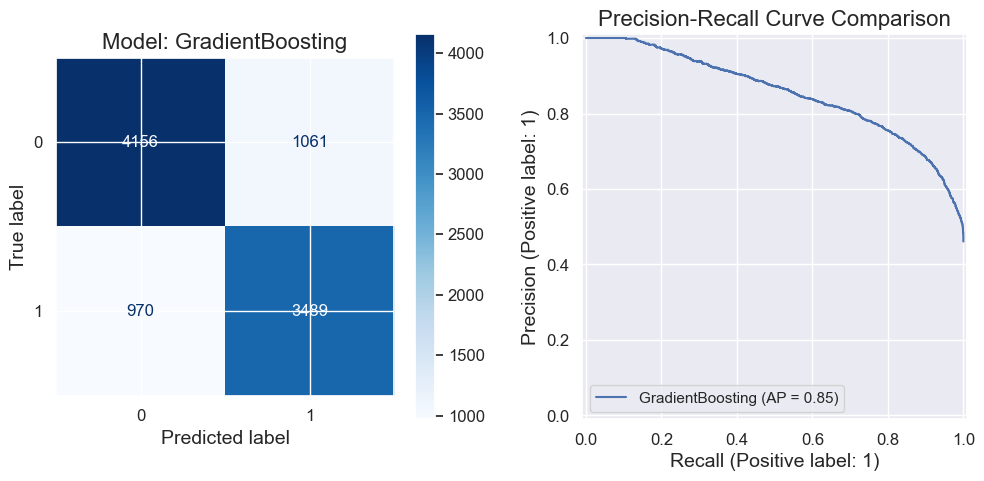

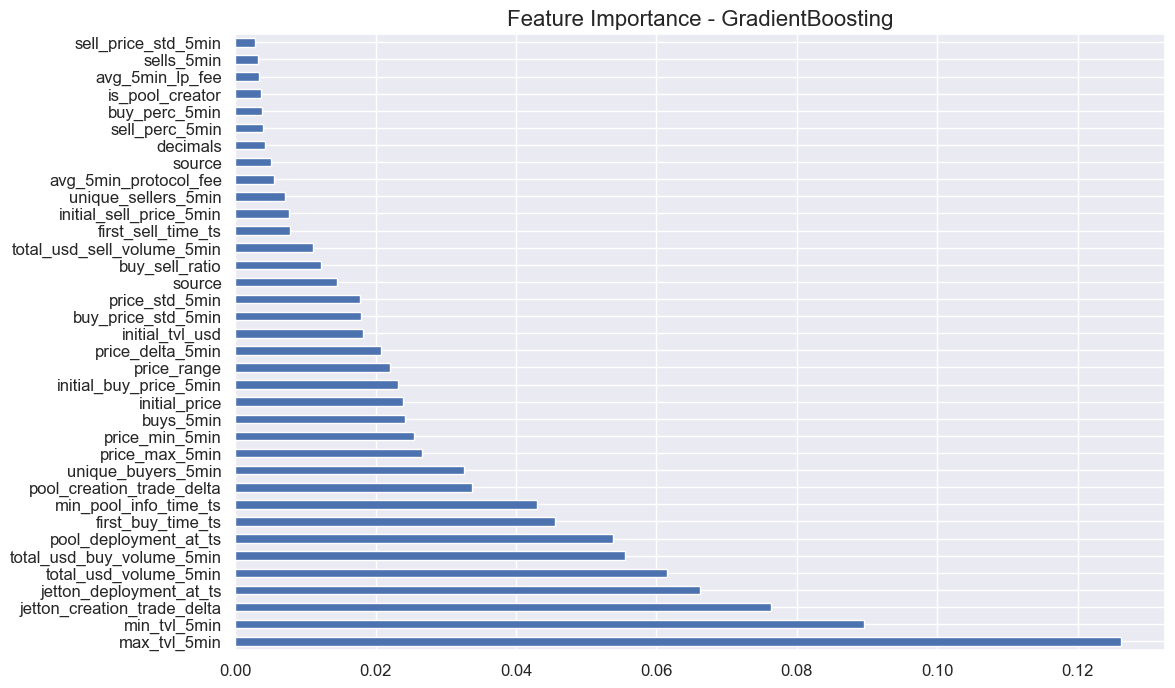

In [40]:
plt.figure(figsize=(10, 6))
for name, res in results.items():
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))
    # confusion_matrix
    cm = confusion_matrix(y_test, res['model'].predict(X_test))
    disp = ConfusionMatrixDisplay(confusion_matrix=cm)
    disp.plot(cmap='Blues', ax=ax1)
    ax1.set_title(f'Model: {name}')
    # График Precision Recall
    PrecisionRecallDisplay.from_estimator(
        res['model'], X_test, y_test, name=name, ax=ax2
    )
    ax2.set_title('Precision-Recall Curve Comparison')
    plt.show()

    # importances фичей
    importances = res['model'].named_steps['classifier'].feature_importances_
    # feature_names = numerical_features + categorical_features + cyclical_features + cyclical_features
    feature_names = numerical_features + time_features + categorical_features + categorical_features

    plt.figure(figsize=(12, 8))
    pd.Series(importances, index=feature_names).nlargest(len(feature_names)).plot(kind='barh')
    plt.title(f'Feature Importance - {name}')
    plt.show()


In [41]:

for model_name, metrics in results.items():
    y_pred = metrics['model'].predict(X_test[X_test['source'] == 'stonfi'])
    y_proba = metrics['model'].predict_proba(X_test[X_test['source'] == 'stonfi'])[:, 1]
    
    print(f"Model: {model_name}")
    print(f"Best CV AUC: {metrics['best_score']:.4f}")
    print(f"Test AUC: {roc_auc_score(y_test[X_test['source'] == 'stonfi'], y_proba):.4f}")
    print("Best Parameters:")
    for param, value in metrics['best_params'].items():
        print(f"  {param}: {value}")
    print("Classification Report:")
    print(metrics['report'])
    print("\n" + "="*80 + "\n")

# Визуализация лучшей модели
best_model_name = max(results, key=lambda x: results[x]['test_auc'])
print(F"BEST MODEL WITH {max([results[x]['test_auc'] for x in results]):.3} AUC IS {best_model_name}")

Model: GradientBoosting
Best CV AUC: 0.8697
Test AUC: 0.8885
Best Parameters:
  classifier__learning_rate: 0.05
  classifier__loss: exponential
  classifier__max_depth: 10
  classifier__max_features: sqrt
  classifier__min_samples_split: 5
  classifier__n_estimators: 200
  classifier__subsample: 1.0
  preprocessor__num__scaler: None
  preprocessor__time__scaler: StandardScaler()
Classification Report:
              precision    recall  f1-score   support

           0       0.81      0.80      0.80      5217
           1       0.77      0.78      0.77      4459

    accuracy                           0.79      9676
   macro avg       0.79      0.79      0.79      9676
weighted avg       0.79      0.79      0.79      9676



BEST MODEL WITH 0.871 AUC IS GradientBoosting


In [42]:

for model_name, metrics in results.items():
    y_pred = metrics['model'].predict(X_test[X_test['source'] == 'dedust'])
    y_proba = metrics['model'].predict_proba(X_test[X_test['source'] == 'dedust'])[:, 1]
    
    print(f"Model: {model_name}")
    print(f"Best CV AUC: {metrics['best_score']:.4f}")
    print(f"Test AUC: {roc_auc_score(y_test[X_test['source'] == 'dedust'], y_proba):.4f}")
    print("Best Parameters:")
    for param, value in metrics['best_params'].items():
        print(f"  {param}: {value}")
    print("Classification Report:")
    print(metrics['report'])
    print("\n" + "="*80 + "\n")

# Визуализация лучшей модели
best_model_name = max(results, key=lambda x: results[x]['test_auc'])
print(F"BEST MODEL WITH {max([results[x]['test_auc'] for x in results]):.3} AUC IS {best_model_name}")

Model: GradientBoosting
Best CV AUC: 0.8697
Test AUC: 0.8317
Best Parameters:
  classifier__learning_rate: 0.05
  classifier__loss: exponential
  classifier__max_depth: 10
  classifier__max_features: sqrt
  classifier__min_samples_split: 5
  classifier__n_estimators: 200
  classifier__subsample: 1.0
  preprocessor__num__scaler: None
  preprocessor__time__scaler: StandardScaler()
Classification Report:
              precision    recall  f1-score   support

           0       0.81      0.80      0.80      5217
           1       0.77      0.78      0.77      4459

    accuracy                           0.79      9676
   macro avg       0.79      0.79      0.79      9676
weighted avg       0.79      0.79      0.79      9676



BEST MODEL WITH 0.871 AUC IS GradientBoosting


# [Idle] Обучение с чекпоинта stonfi
Model: ExtremeGradientBoosting

Best CV AUC: 0.8478 

Test AUC: 0.8397

Best Parameters:
- classifier__colsample_bytree: 0.8
- classifier__gamma: 1
- classifier__learning_rate: 0.1
- classifier__max_depth: 5
- classifier__reg_alpha: 1
- classifier__reg_lambda: 1
- classifier__subsample: 0.8
- preprocessor__num__scaler: None
- preprocessor__time__scaler: None


## Обучение на Stonfi

In [57]:
# Разделение данных
stonfi_df['target'] = stonfi_df['alice_rugpull_60min']
all_features = numerical_features + time_features
X_stonfi = stonfi_df[all_features]
y_stonfi = stonfi_df['target']
X_stonfi_train, X_stonfi_test, y_stonfi_train, y_stonfi_test = train_test_split(
    X_stonfi, y_stonfi, test_size=0.2, stratify=y_stonfi, random_state=42
)

In [58]:
# Конвейер предобработки
numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median'))
])

time_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median'))
])

preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numerical_features),
        ('time', time_transformer, time_features),
    ]
)

preprocessor

ColumnTransformer(transformers=[('num',
                                 Pipeline(steps=[('imputer',
                                                  SimpleImputer(strategy='median'))]),
                                 ['buy_sell_ratio', 'price_range', 'buys_5min',
                                  'sells_5min', 'buy_perc_5min',
                                  'sell_perc_5min', 'unique_buyers_5min',
                                  'unique_sellers_5min',
                                  'total_usd_volume_5min',
                                  'total_usd_buy_volume_5min',
                                  'total_usd_sell_volume_5min', 'decimals',
                                  'avg_5min_lp_fee', 'avg_...
                                  'max_tvl_5min', 'min_tvl_5min',
                                  'buy_price_std_5min',
                                  'initial_sell_price_5min',
                                  'sell_price_std_5min', 'price_max_5min',
                                  'price_min_5min', 'price_delta_5min',
                                  'price_std_5min']),
                                ('time',
                                 Pipeline(steps=[('imputer',
                                                  SimpleImputer(strategy='median'))]),
                                 ['first_buy_time_ts', 'first_sell_time_ts',
                                  'pool_deployment_at_ts',
                                  'jetton_deployment_at_ts',
                                  'min_pool_info_time_ts'])])

In [59]:
# 1. Обучение на stonfi_df
print("Обучение на Stonfi данных...")
stonfi_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', XGBClassifier(
        objective='binary:logistic',
        eval_metric='logloss',
        scale_pos_weight=0.82,
        gamma=1,
        reg_alpha=1,
        reg_lambda=1,
        max_depth=5,
        learning_rate=0.1,
        subsample=0.8,
        colsample_bytree=0.8,
        random_state=42,
        n_jobs=-1
    ))
])

stonfi_pipeline.fit(X_stonfi_train, y_stonfi_train)
y_stonfi_pred = stonfi_pipeline.predict(X_stonfi_test)
y_stonfi_proba = stonfi_pipeline.predict_proba(X_stonfi_test)[:, 1]

{
    'test_auc': roc_auc_score(y_stonfi_test, y_stonfi_proba),
    'report': classification_report(y_stonfi_test, y_stonfi_pred)
}
print(f"Test AUC: {roc_auc_score(y_stonfi_test, y_stonfi_proba):.4f}")
print("Classification Report:")
print(classification_report(y_stonfi_test, y_stonfi_pred))


Обучение на Stonfi данных...
Test AUC: 0.8397
Classification Report:
              precision    recall  f1-score   support

           0       0.79      0.47      0.58       778
           1       0.87      0.97      0.92      2879

    accuracy                           0.86      3657
   macro avg       0.83      0.72      0.75      3657
weighted avg       0.85      0.86      0.85      3657



In [60]:
joblib.dump(stonfi_pipeline, 'model_saves/idle_stonfi_model.pkl')

['model_saves/idle_stonfi_model.pkl']

## Обучение на Dedust

In [61]:
pretrained_model = joblib.load('model_saves/idle_stonfi_model.pkl')
pretrained_booster = pretrained_model.named_steps['classifier'].get_booster()
dedust_df['target'] = dedust_df['alice_rugpull_60min']
dedust_df['version'] = 2
# Разделение данных
dedust_df['target'] = dedust_df['alice_rugpull_60min']
all_features = numerical_features + time_features
X_dedust = preprocessor.transform(dedust_df[all_features])
y_dedust = dedust_df['target']
X_dedust_train, X_dedust_test, y_dedust_train, y_dedust_test = train_test_split(
    X_dedust, y_dedust, test_size=0.2, stratify=y_dedust, random_state=42
)

neg_class_perc = (y_dedust_train == 0).mean()
pos_class_perc = 1 - neg_class_perc

transfer_param_grid = {
    'learning_rate': [0.01, 0.05, 0,1],            # Скорость дообучения
    # 'n_estimators': [50, 100, 200],                # Сколько новых деревьев добавить
    'max_depth': [3, 5, 7, 10],                       # Глубина новых деревьев
    'subsample': [0.8, 1.0],                  # Доля выборки для каждого дерева
    'colsample_bytree': [0.8, 1.0],           # Доля фичей для каждого дерева
    'gamma': [0, 0.5, 1],                          # Минимальное улучшение для разбиения
    'reg_lambda': [1, 2],                     # L2-регуляризация
    'reg_alpha': [0, 0.5],                    # L1-регуляризация
    'scale_pos_weight': [1, neg_class_perc/pos_class_perc, pos_class_perc/neg_class_perc],
}

# CV-стратегия
cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)

# Для каждого сочетания параметров
best_score = -1
best_params = None
best_model = None

for params in ParameterGrid(transfer_param_grid):
    # print("\nПараметры:", params)
    scores = []
    for train_idx, val_idx in cv.split(X_dedust_train, y_dedust_train):
        X_train_cv, X_val = X_dedust_train[train_idx], X_dedust_train[val_idx]
        y_train_cv, y_val = y_dedust_train.iloc[train_idx], y_dedust_train.iloc[val_idx]

        model = XGBClassifier(
            objective='binary:logistic',
            eval_metric='logloss',
            **params,
            random_state=42,
            n_jobs=-1
        )
        model.fit(X_train_cv, y_train_cv, xgb_model=pretrained_booster)

        y_pred_proba = model.predict_proba(X_val)[:, 1]
        score = roc_auc_score(y_val, y_pred_proba)
        scores.append(score)

    mean_score = np.mean(scores)
    # print("Средний ROC-AUC:", mean_score)

    if mean_score > best_score:
        best_score = mean_score
        best_params = params
        best_model = model

for param, value in best_params.items():
        print(f"  {param}: {value}")
print("Лучший ROC-AUC:", best_score)


  colsample_bytree: 0.8
  gamma: 0.5
  learning_rate: 0.05
  max_depth: 10
  reg_alpha: 0.5
  reg_lambda: 2
  scale_pos_weight: 0.24306882131240642
  subsample: 0.8
Лучший ROC-AUC: 0.8102948137843233


In [62]:
# Оценка лучшей модели на всем датасете
best_model.fit(X_dedust_train, y_dedust_train, xgb_model=pretrained_booster)

# Оценка на stonfi_df и dedust_df
# print("\nStonfi AUC:", roc_auc_score(y_stonfi_test, best_model.predict_proba(X_stonfi_test)[:, 1]))
print("Dedust AUC:", roc_auc_score(y_dedust_test, best_model.predict_proba(X_dedust_test)[:, 1]))
print(f"calssification report:\n {classification_report(y_dedust_test, best_model.predict(X_dedust_test))}")

Dedust AUC: 0.8195758016676926
calssification report:
               precision    recall  f1-score   support

           0       0.46      0.64      0.54      1177
           1       0.90      0.82      0.86      4843

    accuracy                           0.79      6020
   macro avg       0.68      0.73      0.70      6020
weighted avg       0.82      0.79      0.80      6020



## Анализ результатов

<Figure size 1000x600 with 0 Axes>

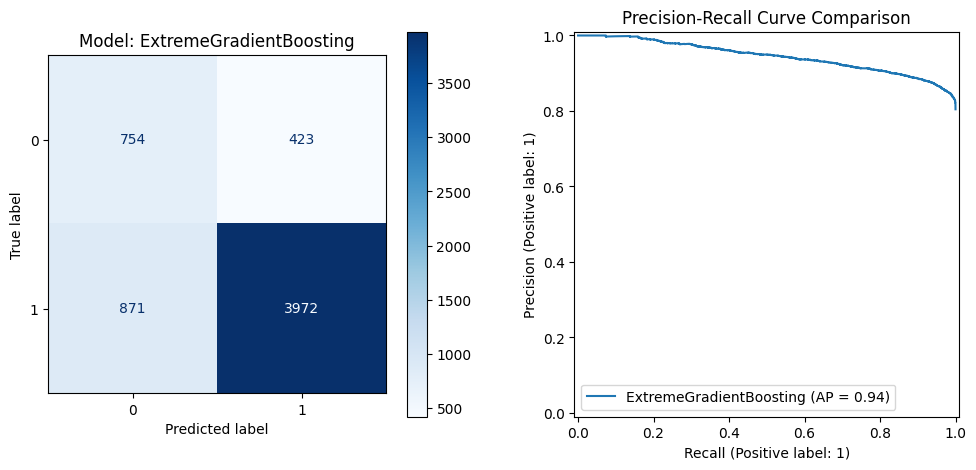

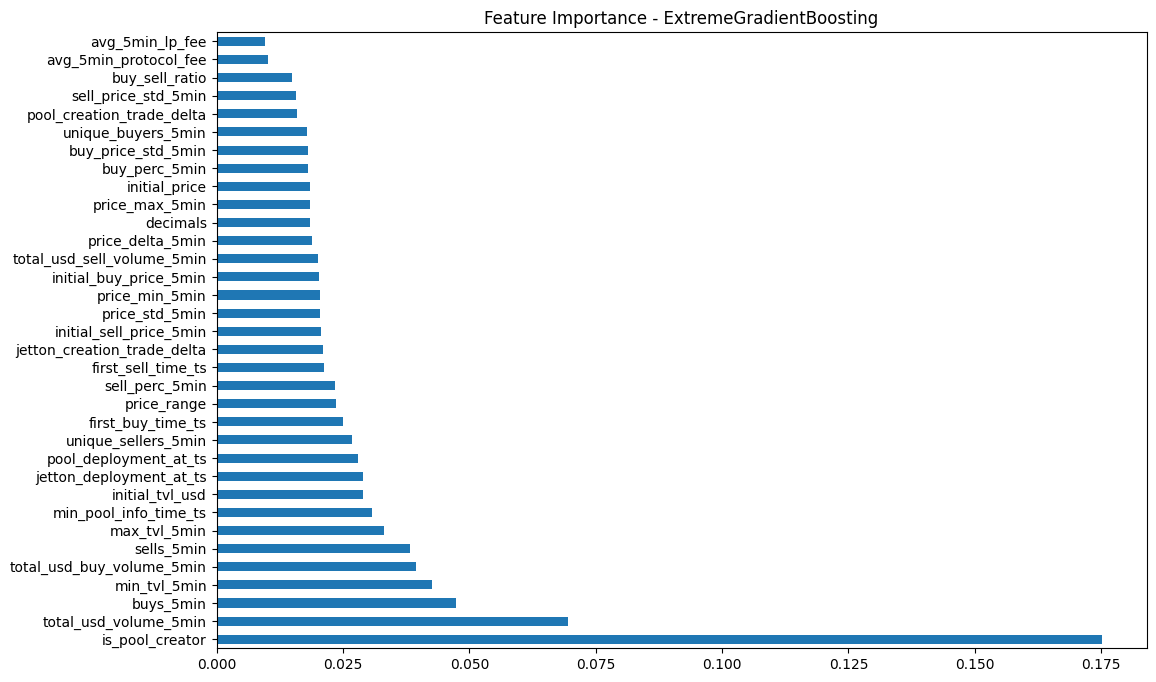

In [63]:
plt.figure(figsize=(10, 6))
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))
# confusion_matrix
cm = confusion_matrix(y_dedust_test, best_model.predict(X_dedust_test))
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(cmap='Blues', ax=ax1)
ax1.set_title(f'Model: ExtremeGradientBoosting')
# График Precision Recall
PrecisionRecallDisplay.from_estimator(
    best_model, X_dedust_test, y_dedust_test, name="ExtremeGradientBoosting", ax=ax2
)
ax2.set_title('Precision-Recall Curve Comparison')
plt.show()

# importances фичей
importances = best_model.feature_importances_
# feature_names = numerical_features + categorical_features + cyclical_features + cyclical_features
feature_names = numerical_features + time_features

plt.figure(figsize=(12, 8))
pd.Series(importances, index=feature_names).nlargest(len(feature_names)).plot(kind='barh')
plt.title(f'Feature Importance - ExtremeGradientBoosting')
plt.show()

# [Idle] Обучение с чекпоинта Dedust
Model: ExtremeGradientBoosting

Best CV AUC: 0.8112 

Test AUC: 0.8203

Best Parameters:
- classifier__colsample_bytree: 1.0
- classifier__gamma: 0
- classifier__learning_rate: 0.05
- classifier__max_depth: 10
- classifier__reg_alpha: 1
- classifier__reg_lambda: 2
- classifier__subsample: 0.8
- preprocessor__num__scaler: None
- preprocessor__time__scaler: None

## Обучение на Dedust

In [64]:
# Разделение данных
dedust_df['target'] = dedust_df['alice_rugpull_60min']
all_features = numerical_features + time_features
X_dedust = dedust_df[all_features]
y_dedust = dedust_df['target']
X_dedust_train, X_dedust_test, y_dedust_train, y_dedust_test = train_test_split(
    X_dedust, y_dedust, test_size=0.2, stratify=y_dedust, random_state=42
)

In [65]:
# Конвейер предобработки
numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median'))
])

time_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median'))
])

preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numerical_features),
        ('time', time_transformer, time_features),
    ]
)

preprocessor

ColumnTransformer(transformers=[('num',
                                 Pipeline(steps=[('imputer',
                                                  SimpleImputer(strategy='median'))]),
                                 ['buy_sell_ratio', 'price_range', 'buys_5min',
                                  'sells_5min', 'buy_perc_5min',
                                  'sell_perc_5min', 'unique_buyers_5min',
                                  'unique_sellers_5min',
                                  'total_usd_volume_5min',
                                  'total_usd_buy_volume_5min',
                                  'total_usd_sell_volume_5min', 'decimals',
                                  'avg_5min_lp_fee', 'avg_...
                                  'max_tvl_5min', 'min_tvl_5min',
                                  'buy_price_std_5min',
                                  'initial_sell_price_5min',
                                  'sell_price_std_5min', 'price_max_5min',
                                  'price_min_5min', 'price_delta_5min',
                                  'price_std_5min']),
                                ('time',
                                 Pipeline(steps=[('imputer',
                                                  SimpleImputer(strategy='median'))]),
                                 ['first_buy_time_ts', 'first_sell_time_ts',
                                  'pool_deployment_at_ts',
                                  'jetton_deployment_at_ts',
                                  'min_pool_info_time_ts'])])

In [66]:
# 1. Обучение на dedust_df
print("Обучение на DeDust данных...")
dedust_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', XGBClassifier(
        objective='binary:logistic',
        eval_metric='logloss',
        scale_pos_weight=0.82,
        gamma=1,
        reg_alpha=1,
        reg_lambda=1,
        max_depth=5,
        learning_rate=0.1,
        subsample=0.8,
        colsample_bytree=0.8,
        random_state=42,
        n_jobs=-1
    ))
])

dedust_pipeline.fit(X_dedust_train, y_dedust_train)
y_dedust_pred = dedust_pipeline.predict(X_dedust_test)
y_dedust_proba = dedust_pipeline.predict_proba(X_dedust_test)[:, 1]

{
    'test_auc': roc_auc_score(y_dedust_test, y_dedust_proba),
    'report': classification_report(y_dedust_test, y_dedust_pred)
}
print(f"Test AUC: {roc_auc_score(y_dedust_test, y_dedust_proba):.4f}")
print("Classification Report:")
print(classification_report(y_dedust_test, y_dedust_pred))


Обучение на DeDust данных...
Test AUC: 0.8168
Classification Report:
              precision    recall  f1-score   support

           0       0.71      0.35      0.47      1177
           1       0.86      0.97      0.91      4843

    accuracy                           0.85      6020
   macro avg       0.78      0.66      0.69      6020
weighted avg       0.83      0.85      0.82      6020



In [67]:
joblib.dump(dedust_pipeline, 'model_saves/idle_dedust_model.pkl')

['model_saves/idle_dedust_model.pkl']

## Обучение на Stonfi

In [68]:
pretrained_model = joblib.load('model_saves/idle_dedust_model.pkl')
pretrained_booster = pretrained_model.named_steps['classifier'].get_booster()
stonfi_df['target'] = stonfi_df['alice_rugpull_60min']
stonfi_df['version'] = 2
# Разделение данных
stonfi_df['target'] = stonfi_df['alice_rugpull_60min']
all_features = numerical_features + time_features
X_stonfi = preprocessor.transform(stonfi_df[all_features])
y_stonfi = stonfi_df['target']
X_stonfi_train, X_stonfi_test, y_stonfi_train, y_stonfi_test = train_test_split(
    X_stonfi, y_stonfi, test_size=0.2, stratify=y_stonfi, random_state=42
)

neg_class_perc = (y_stonfi_train == 0).mean()
pos_class_perc = 1 - neg_class_perc

transfer_param_grid = {
    'learning_rate': [0.01, 0.05, 0,1],            # Скорость дообучения
    # 'n_estimators': [50, 100, 200],                # Сколько новых деревьев добавить
    'max_depth': [3, 5, 7, 10],                       # Глубина новых деревьев
    'subsample': [0.8, 1.0],                  # Доля выборки для каждого дерева
    'colsample_bytree': [0.8, 1.0],           # Доля фичей для каждого дерева
    'gamma': [0, 0.5, 1],                          # Минимальное улучшение для разбиения
    'reg_lambda': [1, 2],                     # L2-регуляризация
    'reg_alpha': [0, 0.5],                    # L1-регуляризация
    'scale_pos_weight': [1, neg_class_perc/pos_class_perc, pos_class_perc/neg_class_perc],
}

# CV-стратегия
cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)

# Для каждого сочетания параметров
best_score = -1
best_params = None
best_model = None

for params in ParameterGrid(transfer_param_grid):
    # print("\nПараметры:", params)
    scores = []
    for train_idx, val_idx in cv.split(X_stonfi_train, y_stonfi_train):
        X_train_cv, X_val = X_stonfi_train[train_idx], X_stonfi_train[val_idx]
        y_train_cv, y_val = y_stonfi_train.iloc[train_idx], y_stonfi_train.iloc[val_idx]

        model = XGBClassifier(
            objective='binary:logistic',
            eval_metric='logloss',
            **params,
            random_state=42,
            n_jobs=-1
        )
        model.fit(X_train_cv, y_train_cv, xgb_model=pretrained_booster)

        y_pred_proba = model.predict_proba(X_val)[:, 1]
        score = roc_auc_score(y_val, y_pred_proba)
        scores.append(score)

    mean_score = np.mean(scores)
    # print("Средний ROC-AUC:", mean_score)

    if mean_score > best_score:
        best_score = mean_score
        best_params = params
        best_model = model

for param, value in best_params.items():
        print(f"  {param}: {value}")
print("Лучший ROC-AUC:", best_score)


  colsample_bytree: 1.0
  gamma: 1
  learning_rate: 0.05
  max_depth: 10
  reg_alpha: 0.5
  reg_lambda: 2
  scale_pos_weight: 3.69987146529563
  subsample: 0.8
Лучший ROC-AUC: 0.8469005122764456


In [69]:
# Оценка лучшей модели на всем датасете
best_model.fit(X_stonfi_train, y_stonfi_train, xgb_model=pretrained_booster)

# Оценка на stonfi_df и dedust_df
print("\nStonfi AUC:", roc_auc_score(y_stonfi_test, best_model.predict_proba(X_stonfi_test)[:, 1]))
# print("Dedust AUC:", roc_auc_score(y_dedust_test, best_model.predict_proba(X_dedust_test)[:, 1]))
print(f"calssification report:\n {classification_report(y_stonfi_test, best_model.predict(X_stonfi_test))}")


Stonfi AUC: 0.8397155717629031
calssification report:
               precision    recall  f1-score   support

           0       0.90      0.37      0.52       778
           1       0.85      0.99      0.92      2879

    accuracy                           0.86      3657
   macro avg       0.88      0.68      0.72      3657
weighted avg       0.86      0.86      0.83      3657



## Анализ результатов

<Figure size 1000x600 with 0 Axes>

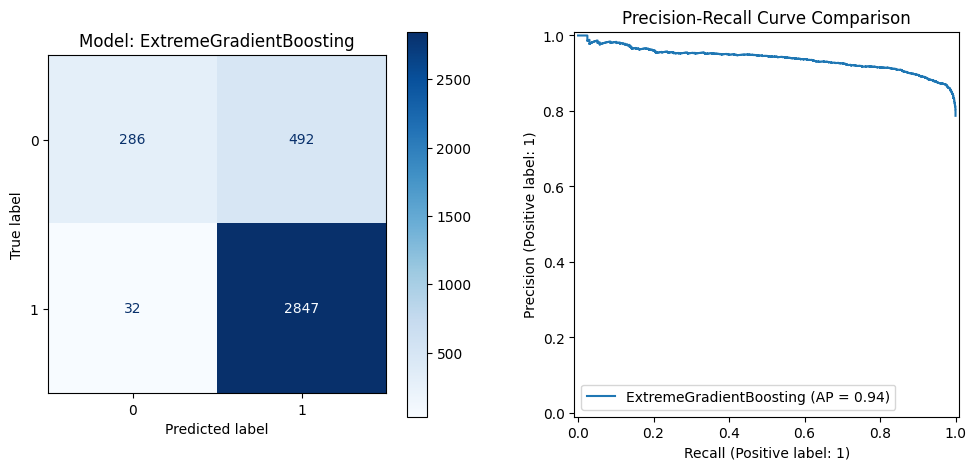

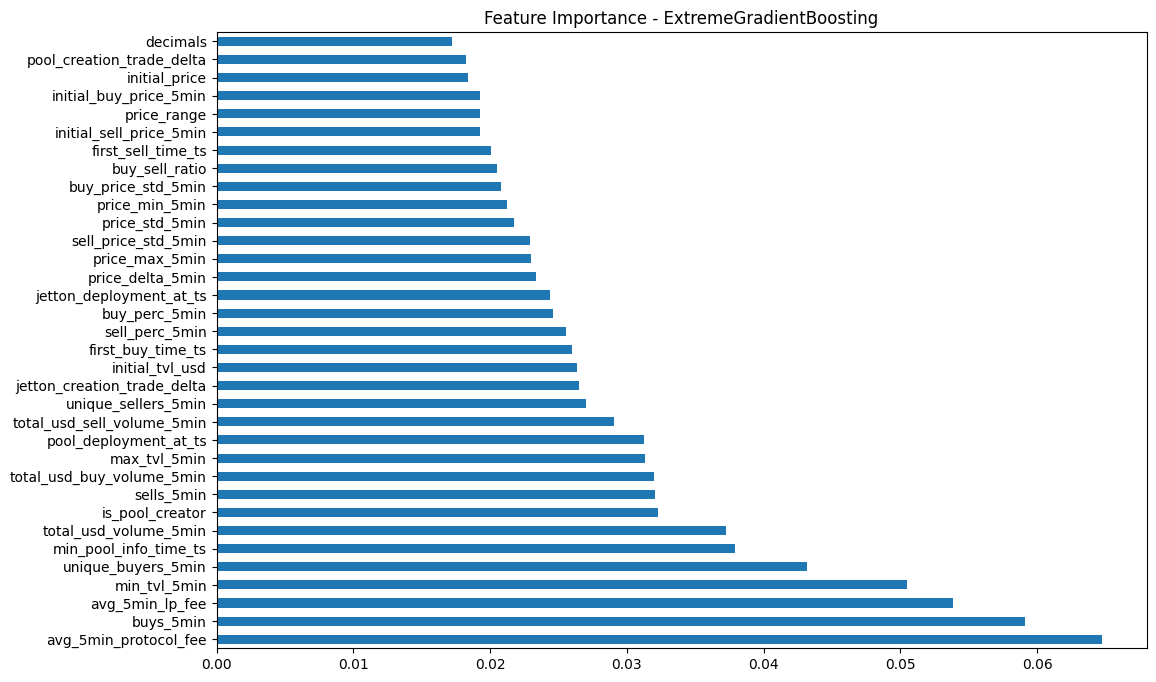

In [70]:
plt.figure(figsize=(10, 6))
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))
# confusion_matrix
cm = confusion_matrix(y_stonfi_test, best_model.predict(X_stonfi_test))
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(cmap='Blues', ax=ax1)
ax1.set_title(f'Model: ExtremeGradientBoosting')
# График Precision Recall
PrecisionRecallDisplay.from_estimator(
    best_model, X_stonfi_test, y_stonfi_test, name="ExtremeGradientBoosting", ax=ax2
)
ax2.set_title('Precision-Recall Curve Comparison')
plt.show()

# importances фичей
importances = best_model.feature_importances_
# feature_names = numerical_features + categorical_features + cyclical_features + cyclical_features
feature_names = numerical_features + time_features

plt.figure(figsize=(12, 8))
pd.Series(importances, index=feature_names).nlargest(len(feature_names)).plot(kind='barh')
plt.title(f'Feature Importance - ExtremeGradientBoosting')
plt.show()

# [TVL] Обучение с чекпоинта stonfi
Model: ExtremeGradientBoosting

Best CV AUC: 0.8851

Test AUC: 0.8825

Best Parameters:
- classifier__colsample_bytree: 1.0
- classifier__gamma: 0
- classifier__learning_rate: 0.1
- classifier__max_depth: 5
- classifier__reg_alpha: 1
- classifier__reg_lambda: 2
- classifier__subsample: 0.8
- preprocessor__num__scaler: StandardScaler()
- preprocessor__time__scaler: None

## Обучение Stonfi

In [71]:
# Разделение данных
stonfi_df['target'] = stonfi_df['tvl_target_60min']
all_features = numerical_features + time_features
X_stonfi = stonfi_df[all_features]
y_stonfi = stonfi_df['target']
X_stonfi_train, X_stonfi_test, y_stonfi_train, y_stonfi_test = train_test_split(
    X_stonfi, y_stonfi, test_size=0.2, stratify=y_stonfi, random_state=42
)

In [72]:
# Конвейер предобработки
numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

time_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median'))
])

preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numerical_features),
        ('time', time_transformer, time_features),
    ]
)

preprocessor

ColumnTransformer(transformers=[('num',
                                 Pipeline(steps=[('imputer',
                                                  SimpleImputer(strategy='median')),
                                                 ('scaler', StandardScaler())]),
                                 ['buy_sell_ratio', 'price_range', 'buys_5min',
                                  'sells_5min', 'buy_perc_5min',
                                  'sell_perc_5min', 'unique_buyers_5min',
                                  'unique_sellers_5min',
                                  'total_usd_volume_5min',
                                  'total_usd_buy_volume_5min',
                                  'total_usd_sell_volume_5min', 'decim...
                                  'max_tvl_5min', 'min_tvl_5min',
                                  'buy_price_std_5min',
                                  'initial_sell_price_5min',
                                  'sell_price_std_5min', 'price_max_5min',
                                  'price_min_5min', 'price_delta_5min',
                                  'price_std_5min']),
                                ('time',
                                 Pipeline(steps=[('imputer',
                                                  SimpleImputer(strategy='median'))]),
                                 ['first_buy_time_ts', 'first_sell_time_ts',
                                  'pool_deployment_at_ts',
                                  'jetton_deployment_at_ts',
                                  'min_pool_info_time_ts'])])

In [73]:
# 1. Обучение на stonfi_df
print("Обучение на Stonfi данных...")
stonfi_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', XGBClassifier(
        objective='binary:logistic',
        eval_metric='logloss',
        scale_pos_weight=0.82,
        gamma=1,
        reg_alpha=1,
        reg_lambda=2,
        max_depth=5,
        learning_rate=0.1,
        subsample=0.8,
        colsample_bytree=1.0,
        random_state=42,
        n_jobs=-1
    ))
])

stonfi_pipeline.fit(X_stonfi_train, y_stonfi_train)
y_stonfi_pred = stonfi_pipeline.predict(X_stonfi_test)
y_stonfi_proba = stonfi_pipeline.predict_proba(X_stonfi_test)[:, 1]

{
    'test_auc': roc_auc_score(y_stonfi_test, y_stonfi_proba),
    'report': classification_report(y_stonfi_test, y_stonfi_pred)
}
print(f"Test AUC: {roc_auc_score(y_stonfi_test, y_stonfi_proba):.4f}")
print("Classification Report:")
print(classification_report(y_stonfi_test, y_stonfi_pred))


Обучение на Stonfi данных...
Test AUC: 0.8834
Classification Report:
              precision    recall  f1-score   support

           0       0.85      0.93      0.89      2626
           1       0.77      0.58      0.66      1031

    accuracy                           0.83      3657
   macro avg       0.81      0.76      0.77      3657
weighted avg       0.83      0.83      0.82      3657



In [74]:
joblib.dump(stonfi_pipeline, 'model_saves/tvl_stonfi_model.pkl')

['model_saves/tvl_stonfi_model.pkl']

## Обучение на Dedust

In [75]:
pretrained_model = joblib.load('model_saves/tvl_stonfi_model.pkl')
pretrained_booster = pretrained_model.named_steps['classifier'].get_booster()
dedust_df['target'] = dedust_df['tvl_target_60min']
dedust_df['version'] = 2
# Разделение данных
all_features = numerical_features + time_features
X_dedust = preprocessor.transform(dedust_df[all_features])
y_dedust = dedust_df['target']
X_dedust_train, X_dedust_test, y_dedust_train, y_dedust_test = train_test_split(
    X_dedust, y_dedust, test_size=0.2, stratify=y_dedust, random_state=42
)

neg_class_perc = (y_dedust_train == 0).mean()
pos_class_perc = 1 - neg_class_perc

transfer_param_grid = {
    'learning_rate': [0.01, 0.05, 0,1],            # Скорость дообучения
    # 'n_estimators': [50, 100, 200],                # Сколько новых деревьев добавить
    'max_depth': [3, 5, 7, 10],                       # Глубина новых деревьев
    'subsample': [0.8, 1.0],                  # Доля выборки для каждого дерева
    'colsample_bytree': [0.8, 1.0],           # Доля фичей для каждого дерева
    'gamma': [0, 0.5, 1],                          # Минимальное улучшение для разбиения
    'reg_lambda': [1, 2],                     # L2-регуляризация
    'reg_alpha': [0, 0.5],                    # L1-регуляризация
    'scale_pos_weight': [1, neg_class_perc/pos_class_perc, pos_class_perc/neg_class_perc],
}

# CV-стратегия
cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)

# Для каждого сочетания параметров
best_score = -1
best_params = None
best_model = None

for params in ParameterGrid(transfer_param_grid):
    # print("\nПараметры:", params)
    scores = []
    for train_idx, val_idx in cv.split(X_dedust_train, y_dedust_train):
        X_train_cv, X_val = X_dedust_train[train_idx], X_dedust_train[val_idx]
        y_train_cv, y_val = y_dedust_train.iloc[train_idx], y_dedust_train.iloc[val_idx]

        model = XGBClassifier(
            objective='binary:logistic',
            eval_metric='logloss',
            **params,
            random_state=42,
            n_jobs=-1
        )
        model.fit(X_train_cv, y_train_cv, xgb_model=pretrained_booster)

        y_pred_proba = model.predict_proba(X_val)[:, 1]
        score = roc_auc_score(y_val, y_pred_proba)
        scores.append(score)

    mean_score = np.mean(scores)
    # print("Средний ROC-AUC:", mean_score)

    if mean_score > best_score:
        best_score = mean_score
        best_params = params
        best_model = model

for param, value in best_params.items():
        print(f"  {param}: {value}")
print("Лучший ROC-AUC:", best_score)


  colsample_bytree: 0.8
  gamma: 1
  learning_rate: 0.05
  max_depth: 10
  reg_alpha: 0.5
  reg_lambda: 1
  scale_pos_weight: 1
  subsample: 0.8
Лучший ROC-AUC: 0.824350615099775


In [76]:
# Оценка лучшей модели на всем датасете
best_model.fit(X_dedust_train, y_dedust_train, xgb_model=pretrained_booster)

# Оценка на stonfi_df и dedust_df
# print("\nStonfi AUC:", roc_auc_score(y_stonfi_test, best_model.predict_proba(X_stonfi_test)[:, 1]))
print("Dedust AUC:", roc_auc_score(y_dedust_test, best_model.predict_proba(X_dedust_test)[:, 1]))
print(f"calssification report:\n {classification_report(y_dedust_test, best_model.predict(X_dedust_test))}")


Dedust AUC: 0.8257317571570117
calssification report:
               precision    recall  f1-score   support

           0       0.72      0.67      0.69      2591
           1       0.76      0.81      0.78      3429

    accuracy                           0.75      6020
   macro avg       0.74      0.74      0.74      6020
weighted avg       0.74      0.75      0.74      6020



## Анализ результатов

<Figure size 1000x600 with 0 Axes>

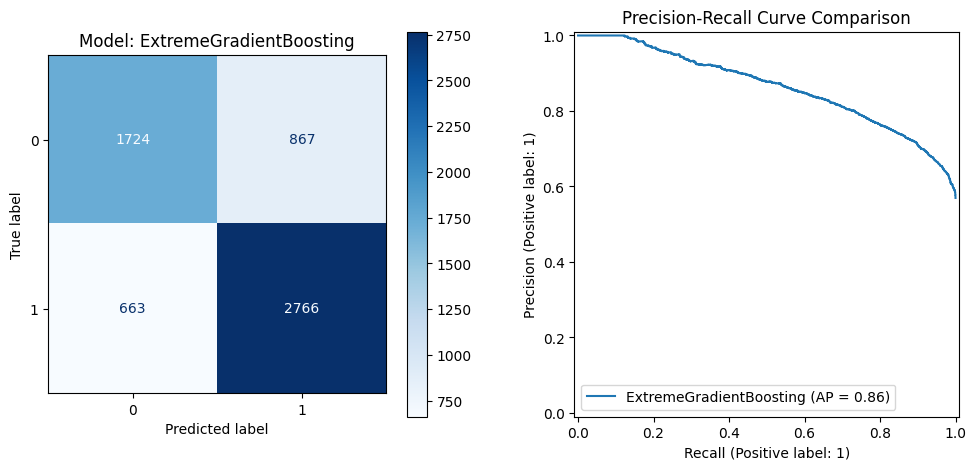

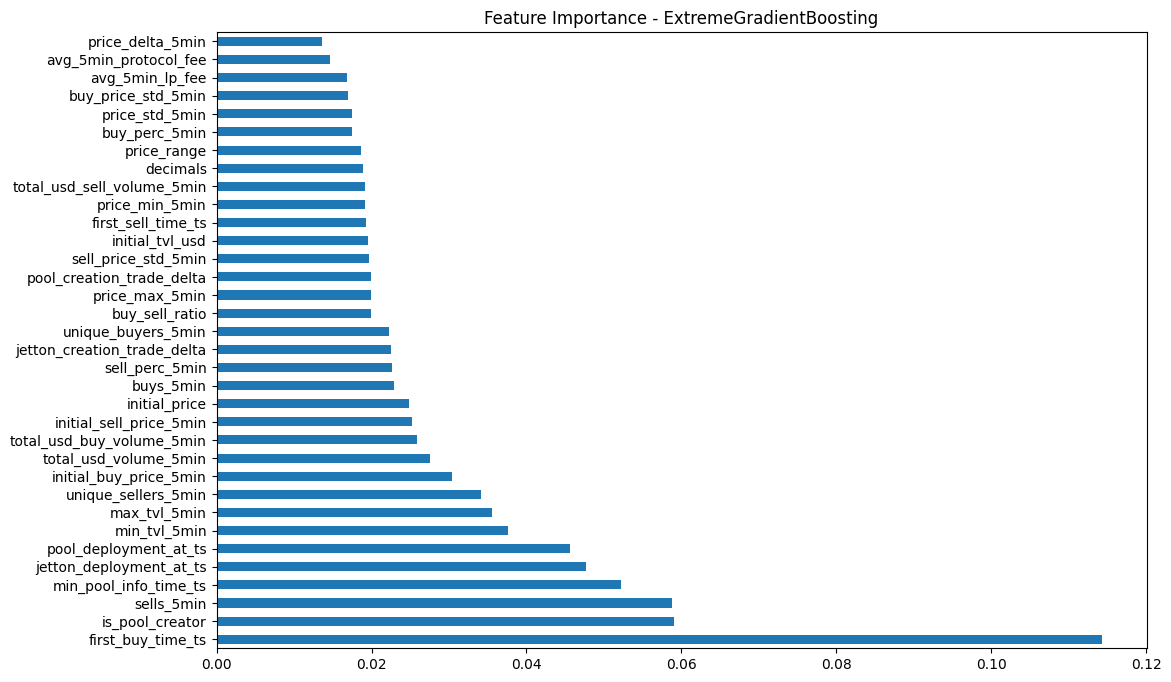

In [77]:
plt.figure(figsize=(10, 6))
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))
# confusion_matrix
cm = confusion_matrix(y_dedust_test, best_model.predict(X_dedust_test))
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(cmap='Blues', ax=ax1)
ax1.set_title(f'Model: ExtremeGradientBoosting')
# График Precision Recall
PrecisionRecallDisplay.from_estimator(
    best_model, X_dedust_test, y_dedust_test, name="ExtremeGradientBoosting", ax=ax2
)
ax2.set_title('Precision-Recall Curve Comparison')
plt.show()

# importances фичей
importances = best_model.feature_importances_
# feature_names = numerical_features + categorical_features + cyclical_features + cyclical_features
feature_names = numerical_features + time_features

plt.figure(figsize=(12, 8))
pd.Series(importances, index=feature_names).nlargest(len(feature_names)).plot(kind='barh')
plt.title(f'Feature Importance - ExtremeGradientBoosting')
plt.show()

# [TVL] Обучение с чекпоинта Dedust
Model: ExtremeGradientBoosting

Best CV AUC: 0.8898

Test AUC: 0.8867

Best Parameters:
- classifier__colsample_bytree: 0.8
- classifier__gamma: 0
- classifier__learning_rate: 0.1
- classifier__max_depth: 10
- classifier__reg_alpha: 1
- classifier__reg_lambda: 1.5
- classifier__subsample: 1.0

## Обучение Dedust

In [78]:
# Разделение данных
dedust_df['target'] = dedust_df['tvl_target_60min']
all_features = numerical_features + time_features
X_dedust = dedust_df[all_features]
y_dedust = dedust_df['target']
X_dedust_train, X_dedust_test, y_dedust_train, y_dedust_test = train_test_split(
    X_dedust, y_dedust, test_size=0.2, stratify=y_dedust, random_state=42
)

In [79]:
# Конвейер предобработки
numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    # ('scaler', StandardScaler())
])

time_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median'))
])

preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numerical_features),
        ('time', time_transformer, time_features),
    ]
)

preprocessor

ColumnTransformer(transformers=[('num',
                                 Pipeline(steps=[('imputer',
                                                  SimpleImputer(strategy='median'))]),
                                 ['buy_sell_ratio', 'price_range', 'buys_5min',
                                  'sells_5min', 'buy_perc_5min',
                                  'sell_perc_5min', 'unique_buyers_5min',
                                  'unique_sellers_5min',
                                  'total_usd_volume_5min',
                                  'total_usd_buy_volume_5min',
                                  'total_usd_sell_volume_5min', 'decimals',
                                  'avg_5min_lp_fee', 'avg_...
                                  'max_tvl_5min', 'min_tvl_5min',
                                  'buy_price_std_5min',
                                  'initial_sell_price_5min',
                                  'sell_price_std_5min', 'price_max_5min',
                                  'price_min_5min', 'price_delta_5min',
                                  'price_std_5min']),
                                ('time',
                                 Pipeline(steps=[('imputer',
                                                  SimpleImputer(strategy='median'))]),
                                 ['first_buy_time_ts', 'first_sell_time_ts',
                                  'pool_deployment_at_ts',
                                  'jetton_deployment_at_ts',
                                  'min_pool_info_time_ts'])])

In [80]:
# 1. Обучение на dedust_df
print("Обучение на dedust данных...")
dedust_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', XGBClassifier(
        objective='binary:logistic',
        eval_metric='logloss',
        scale_pos_weight=0.82,
        gamma=0,
        reg_alpha=1,
        reg_lambda=1.5,
        max_depth=10,
        learning_rate=0.1,
        subsample=1.0,
        colsample_bytree=0.8,
        random_state=42,
        n_jobs=-1
    ))
])

dedust_pipeline.fit(X_dedust_train, y_dedust_train)
y_dedust_pred = dedust_pipeline.predict(X_dedust_test)
y_dedust_proba = dedust_pipeline.predict_proba(X_dedust_test)[:, 1]

{
    'test_auc': roc_auc_score(y_dedust_test, y_dedust_proba),
    'report': classification_report(y_dedust_test, y_dedust_pred)
}
print(f"Test AUC: {roc_auc_score(y_dedust_test, y_dedust_proba):.4f}")
print("Classification Report:")
print(classification_report(y_dedust_test, y_dedust_pred))


Обучение на dedust данных...
Test AUC: 0.8288
Classification Report:
              precision    recall  f1-score   support

           0       0.71      0.70      0.71      2591
           1       0.78      0.78      0.78      3429

    accuracy                           0.75      6020
   macro avg       0.74      0.74      0.74      6020
weighted avg       0.75      0.75      0.75      6020



In [81]:
joblib.dump(dedust_pipeline, 'model_saves/tvl_dedust_model.pkl')

['model_saves/tvl_dedust_model.pkl']

## Обучение на Stonfi

In [82]:
pretrained_model = joblib.load('model_saves/tvl_dedust_model.pkl')
pretrained_booster = pretrained_model.named_steps['classifier'].get_booster()
stonfi_df['target'] = stonfi_df['tvl_target_60min']
stonfi_df['version'] = 2
# Разделение данных
all_features = numerical_features + time_features
X_stonfi = preprocessor.transform(stonfi_df[all_features])
y_stonfi = stonfi_df['target']
X_stonfi_train, X_stonfi_test, y_stonfi_train, y_stonfi_test = train_test_split(
    X_stonfi, y_stonfi, test_size=0.2, stratify=y_stonfi, random_state=42
)

neg_class_perc = (y_stonfi_train == 0).mean()
pos_class_perc = 1 - neg_class_perc

transfer_param_grid = {
    'learning_rate': [0.01, 0.05, 0,1],            # Скорость дообучения
    # 'n_estimators': [50, 100, 200],                # Сколько новых деревьев добавить
    'max_depth': [3, 5, 7, 10],                       # Глубина новых деревьев
    'subsample': [0.8, 1.0],                  # Доля выборки для каждого дерева
    'colsample_bytree': [0.8, 1.0],           # Доля фичей для каждого дерева
    'gamma': [0, 0.5, 1],                          # Минимальное улучшение для разбиения
    'reg_lambda': [1, 2],                     # L2-регуляризация
    'reg_alpha': [0, 0.5],                    # L1-регуляризация
    'scale_pos_weight': [1, neg_class_perc/pos_class_perc, pos_class_perc/neg_class_perc],
}

# CV-стратегия
cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)

# Для каждого сочетания параметров
best_score = -1
best_params = None
best_model = None

for params in ParameterGrid(transfer_param_grid):
    # print("\nПараметры:", params)
    scores = []
    for train_idx, val_idx in cv.split(X_stonfi_train, y_stonfi_train):
        X_train_cv, X_val = X_stonfi_train[train_idx], X_stonfi_train[val_idx]
        y_train_cv, y_val = y_stonfi_train.iloc[train_idx], y_stonfi_train.iloc[val_idx]

        model = XGBClassifier(
            objective='binary:logistic',
            eval_metric='logloss',
            **params,
            random_state=42,
            n_jobs=-1
        )
        model.fit(X_train_cv, y_train_cv, xgb_model=pretrained_booster)

        y_pred_proba = model.predict_proba(X_val)[:, 1]
        score = roc_auc_score(y_val, y_pred_proba)
        scores.append(score)

    mean_score = np.mean(scores)
    # print("Средний ROC-AUC:", mean_score)

    if mean_score > best_score:
        best_score = mean_score
        best_params = params
        best_model = model

for param, value in best_params.items():
        print(f"  {param}: {value}")
print("Лучший ROC-AUC:", best_score)


  colsample_bytree: 1.0
  gamma: 0.5
  learning_rate: 0.05
  max_depth: 10
  reg_alpha: 0
  reg_lambda: 1
  scale_pos_weight: 1
  subsample: 0.8
Лучший ROC-AUC: 0.882859689500509


In [83]:
# Оценка лучшей модели на всем датасете
best_model.fit(X_stonfi_train, y_stonfi_train, xgb_model=pretrained_booster)

# Оценка на stonfi_df и dedust_df
print("\nStonfi AUC:", roc_auc_score(y_stonfi_test, best_model.predict_proba(X_stonfi_test)[:, 1]))
# print("Dedust AUC:", roc_auc_score(y_dedust_test, best_model.predict_proba(X_dedust_test)[:, 1]))
print(f"calssification report:\n {classification_report(y_stonfi_test, best_model.predict(X_stonfi_test))}")


Stonfi AUC: 0.8846257266180249
calssification report:
               precision    recall  f1-score   support

           0       0.87      0.91      0.89      2626
           1       0.74      0.65      0.69      1031

    accuracy                           0.84      3657
   macro avg       0.81      0.78      0.79      3657
weighted avg       0.83      0.84      0.83      3657



## Анализ результатов

<Figure size 1000x600 with 0 Axes>

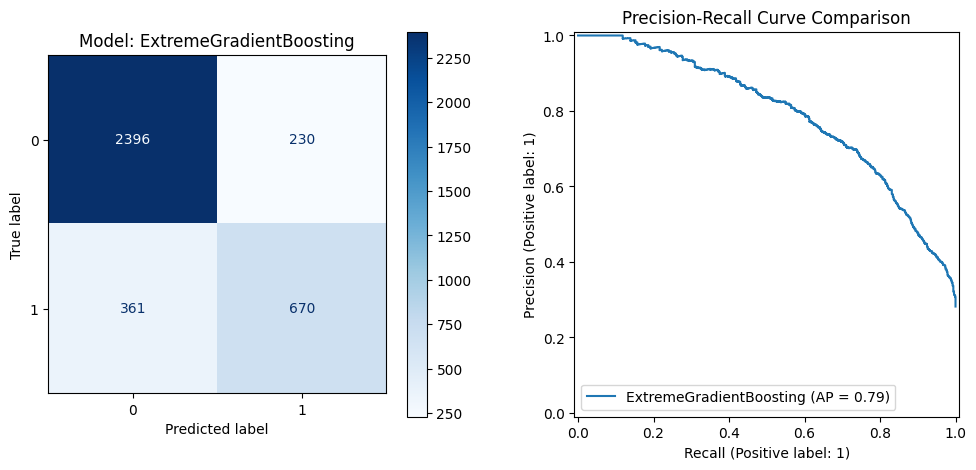

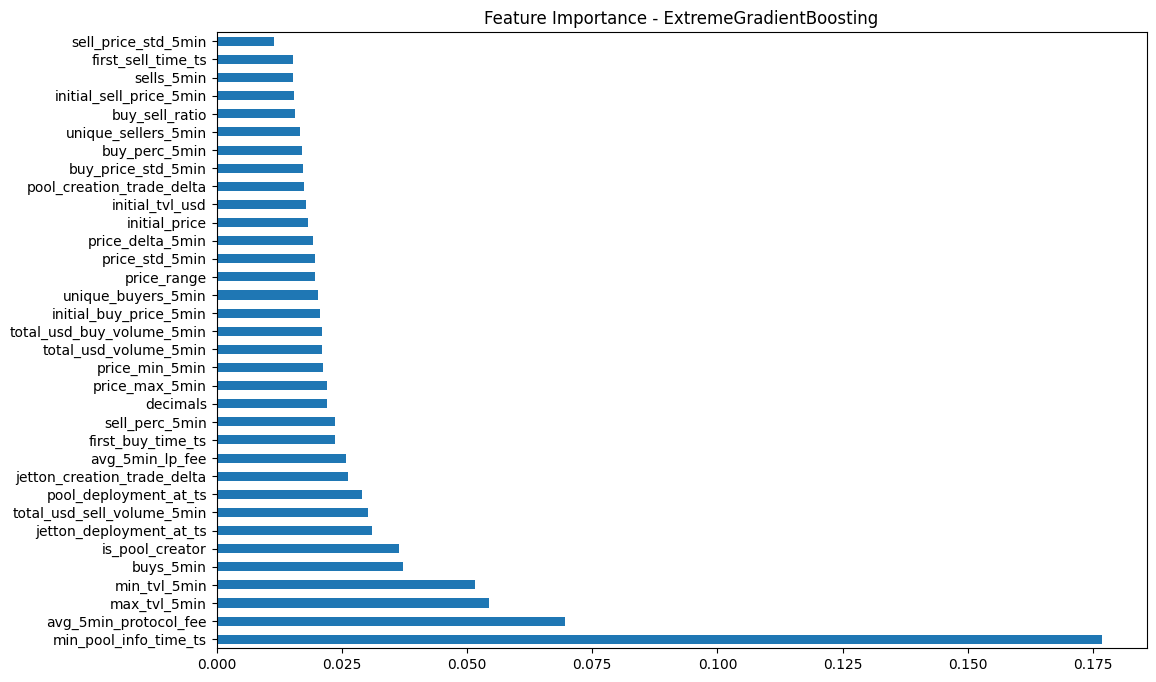

In [84]:
plt.figure(figsize=(10, 6))
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))
# confusion_matrix
cm = confusion_matrix(y_stonfi_test, best_model.predict(X_stonfi_test))
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(cmap='Blues', ax=ax1)
ax1.set_title(f'Model: ExtremeGradientBoosting')
# График Precision Recall
PrecisionRecallDisplay.from_estimator(
    best_model, X_stonfi_test, y_stonfi_test, name="ExtremeGradientBoosting", ax=ax2
)
ax2.set_title('Precision-Recall Curve Comparison')
plt.show()

# importances фичей
importances = best_model.feature_importances_
# feature_names = numerical_features + categorical_features + cyclical_features + cyclical_features
feature_names = numerical_features + time_features

plt.figure(figsize=(12, 8))
pd.Series(importances, index=feature_names).nlargest(len(feature_names)).plot(kind='barh')
plt.title(f'Feature Importance - ExtremeGradientBoosting')
plt.show()

# Correlation

In [ ]:
stonfi_df[numerical_features + ['target']].corr()

# Ad-hoc

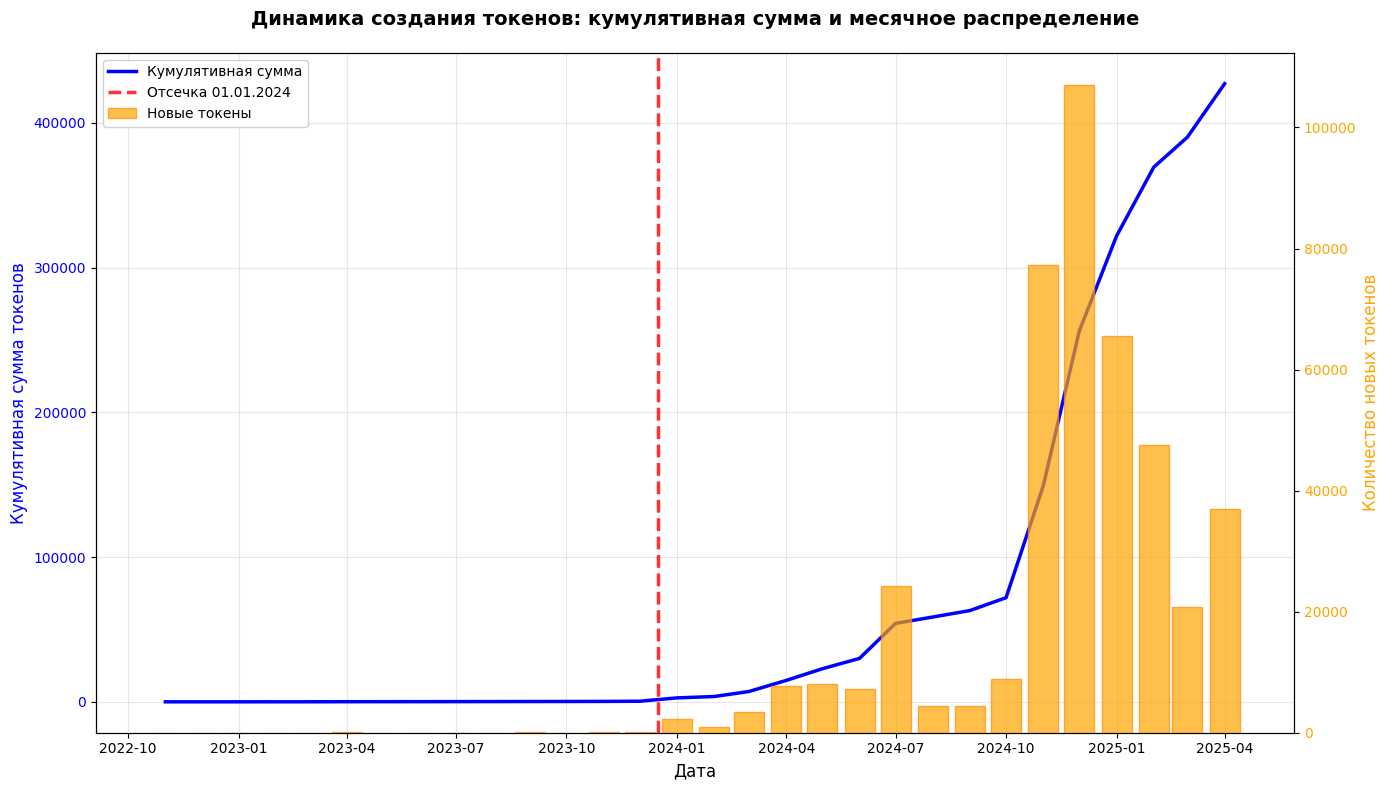

In [1]:
import matplotlib.pyplot as plt
import pandas as pd
from io import StringIO

# Исходные данные
data = '''month_,cum_sum,token_cnt
2022-11-01 00:00,3,3
2022-12-01 00:00,8,5
2023-01-01 00:00,10,2
2023-02-01 00:00,27,17
2023-03-01 00:00,31,4
2023-04-01 00:00,73,42
2023-05-01 00:00,92,19
2023-06-01 00:00,109,17
2023-07-01 00:00,137,28
2023-08-01 00:00,163,26
2023-09-01 00:00,202,39
2023-10-01 00:00,237,35
2023-11-01 00:00,281,44
2023-12-01 00:00,413,132
2024-01-01 00:00,2717,2304
2024-02-01 00:00,3665,948
2024-03-01 00:00,7147,3482
2024-04-01 00:00,14799,7652
2024-05-01 00:00,22846,8047
2024-06-01 00:00,30012,7166
2024-07-01 00:00,54190,24178
2024-08-01 00:00,58588,4398
2024-09-01 00:00,63078,4490
2024-10-01 00:00,71952,8874
2024-11-01 00:00,149249,77297
2024-12-01 00:00,256237,106988
2025-01-01 00:00,321839,65602
2025-02-01 00:00,369435,47596
2025-03-01 00:00,390155,20720
2025-04-01 00:00,427108,36953'''

df = pd.read_csv(StringIO(data), parse_dates=['month_'])

# Создание объединенного графика
fig, ax1 = plt.subplots(figsize=(14, 8))

# Кумулятивная сумма (основная ось Y)
line = ax1.plot(df['month_'], df['cum_sum'], 'b-', linewidth=2.5, label='Кумулятивная сумма')
ax1.set_ylabel('Кумулятивная сумма токенов', color='b', fontsize=12)
ax1.tick_params(axis='y', labelcolor='b')
ax1.grid(True, alpha=0.3)

# Распределение токенов (вторичная ось Y с увеличенной шириной бинов)
ax2 = ax1.twinx()
bars = ax2.bar(df['month_'], df['token_cnt'], color='orange', width=25, 
               label='Новые токены', alpha=0.7, edgecolor='darkorange', linewidth=1)
ax2.set_ylabel('Количество новых токенов', color='orange', fontsize=12)
ax2.tick_params(axis='y', labelcolor='orange')

# Отсечка на 01.01.2024
cutoff_date = pd.to_datetime('2023-12-16')
ax1.axvline(x=cutoff_date, color='red', linestyle='--', linewidth=2.5, 
           label='Отсечка 01.01.2024', alpha=0.8)

# Оформление
ax1.set_xlabel('Дата', fontsize=12)
plt.title('Динамика создания токенов: кумулятивная сумма и месячное распределение', 
          fontsize=14, fontweight='bold', pad=20)

# Легенда
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper left', framealpha=0.9)

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


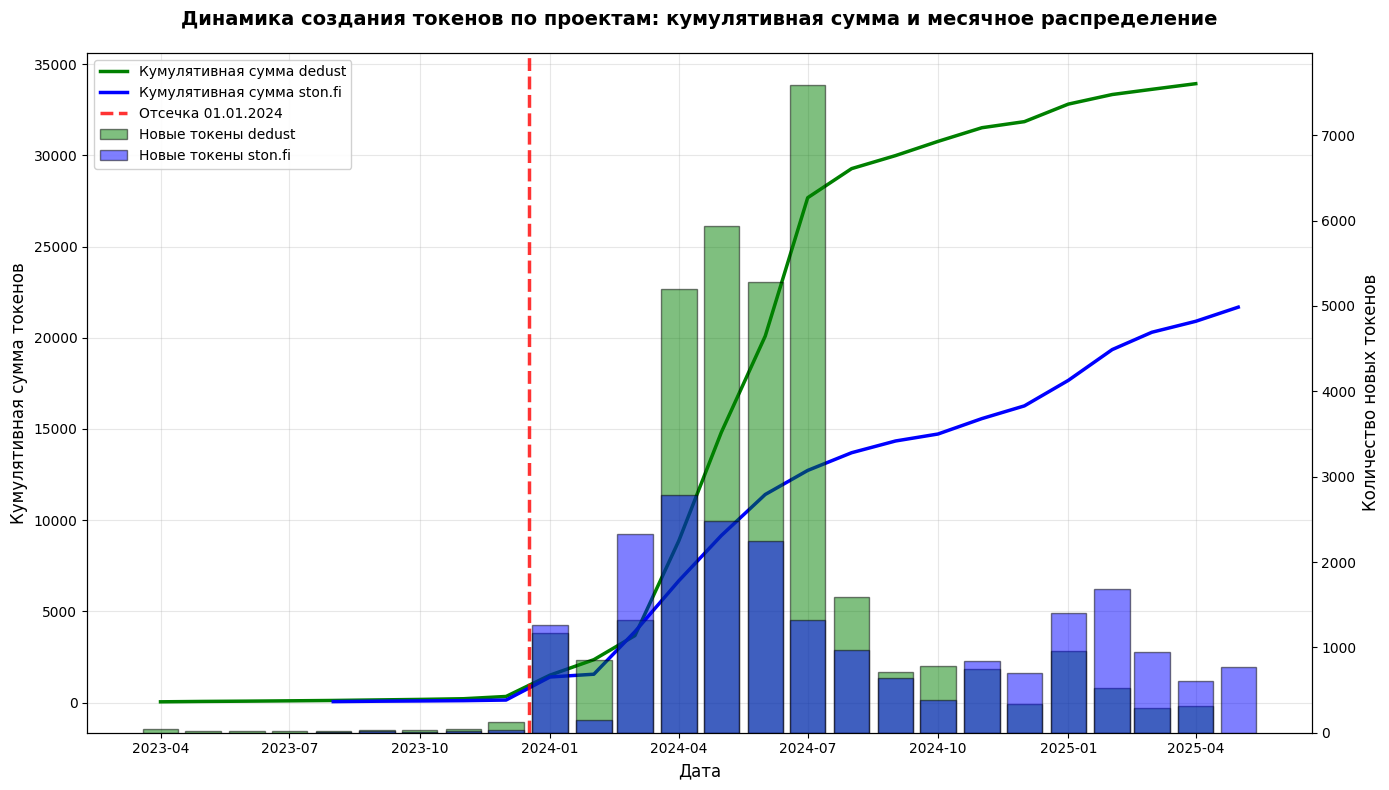

In [2]:
import matplotlib.pyplot as plt
import pandas as pd
from io import StringIO

# Данные с разбивкой по проектам
raw_data = '''month_,project,cum_sum,token_cnt
2023-04-01 00:00,dedust,43,43
2023-05-01 00:00,dedust,64,21
2023-06-01 00:00,dedust,79,15
2023-07-01 00:00,dedust,97,18
2023-08-01 00:00,dedust,117,20
2023-09-01 00:00,dedust,146,29
2023-10-01 00:00,dedust,174,28
2023-11-01 00:00,dedust,212,38
2023-12-01 00:00,dedust,336,124
2024-01-01 00:00,dedust,1505,1169
2024-02-01 00:00,dedust,2353,848
2024-03-01 00:00,dedust,3674,1321
2024-04-01 00:00,dedust,8873,5199
2024-05-01 00:00,dedust,14814,5941
2024-06-01 00:00,dedust,20089,5275
2024-07-01 00:00,dedust,27676,7587
2024-08-01 00:00,dedust,29270,1594
2024-09-01 00:00,dedust,29984,714
2024-10-01 00:00,dedust,30763,779
2024-11-01 00:00,dedust,31512,749
2024-12-01 00:00,dedust,31845,333
2025-01-01 00:00,dedust,32806,961
2025-02-01 00:00,dedust,33332,526
2025-03-01 00:00,dedust,33617,285
2025-04-01 00:00,dedust,33926,309
2023-08-01 00:00,ston.fi,54,13
2023-09-01 00:00,ston.fi,76,22
2023-10-01 00:00,ston.fi,90,14
2023-11-01 00:00,ston.fi,107,17
2023-12-01 00:00,ston.fi,140,33
2024-01-01 00:00,ston.fi,1403,1263
2024-02-01 00:00,ston.fi,1556,153
2024-03-01 00:00,ston.fi,3889,2333
2024-04-01 00:00,ston.fi,6679,2790
2024-05-01 00:00,ston.fi,9157,2478
2024-06-01 00:00,ston.fi,11408,2251
2024-07-01 00:00,ston.fi,12727,1319
2024-08-01 00:00,ston.fi,13697,970
2024-09-01 00:00,ston.fi,14340,643
2024-10-01 00:00,ston.fi,14723,383
2024-11-01 00:00,ston.fi,15568,845
2024-12-01 00:00,ston.fi,16265,697
2025-01-01 00:00,ston.fi,17662,1397
2025-02-01 00:00,ston.fi,19350,1688
2025-03-01 00:00,ston.fi,20300,950
2025-04-01 00:00,ston.fi,20901,601
2025-05-01 00:00,ston.fi,21676,775'''

df = pd.read_csv(StringIO(raw_data), parse_dates=['month_'])

# Цвета для проектов
colors = {'ston.fi': 'blue', 'dedust': 'green'}

fig, ax1 = plt.subplots(figsize=(14, 8))

# Построение кумулятивной суммы для каждого проекта
for project in df['project'].unique():
    proj_data = df[df['project'] == project]
    ax1.plot(proj_data['month_'], proj_data['cum_sum'], 
             label=f'Кумулятивная сумма {project}', 
             color=colors.get(project, 'black'), linewidth=2.5)

ax1.set_ylabel('Кумулятивная сумма токенов', fontsize=12)
ax1.tick_params(axis='y')
ax1.grid(True, alpha=0.3)

# Вторая ось для распределения токенов
ax2 = ax1.twinx()

# Построение распределения токенов для каждого проекта
for project in df['project'].unique():
    proj_data = df[df['project'] == project]
    ax2.bar(proj_data['month_'], proj_data['token_cnt'], width=25, alpha=0.5, 
            label=f'Новые токены {project}', 
            color=colors.get(project, 'black'), edgecolor='black')

ax2.set_ylabel('Количество новых токенов', fontsize=12)
ax2.tick_params(axis='y')

# Отсечка на 01.01.2024
cutoff_date = pd.to_datetime('2023-12-17')
ax1.axvline(x=cutoff_date, color='red', linestyle='--', linewidth=2.5, 
           label='Отсечка 01.01.2024', alpha=0.8)

# Оформление
ax1.set_xlabel('Дата', fontsize=12)
plt.title('Динамика создания токенов по проектам: кумулятивная сумма и месячное распределение', 
          fontsize=14, fontweight='bold', pad=20)

# Объединенная легенда
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper left', framealpha=0.9)

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


In [ ]:
pd.read_csv('---CVAUC-TestAUC-.csv')

## график про разметку данных

In [ ]:
stonfi_idle_x = ['10 min','30 min','60 min','120 min','180 min','240 min','300 min','360 min','420 min']
stonfi_idle_y = [f"{stonfi_df['alice_rugpull_' + i.replace(' ', '')].mean()*100:.3}%" for i in x]
stonfi_tvl_y = [f"{((stonfi_df['max_tvl_' + i.replace(' ','')] - stonfi_df['min_tvl_t_to_' + i.replace(' ','')]) / stonfi_df['max_tvl_' + i.replace(' ','')] > 0.99).astype(int).mean() * 100:.3}%" for i in x]
dedust_idle_y = [f"{dedust_df['alice_rugpull_' + i.replace(' ', '')].mean()*100:.3}%" for i in x]
dedust_tvl_y = [f"{((dedust_df['max_tvl_' + i.replace(' ','')] - dedust_df['min_tvl_t_to_' + i.replace(' ','')]) / dedust_df['max_tvl_' + i.replace(' ','')] > 0.99).astype(int).mean() * 100:.3}%" for i in x]


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.colors import LinearSegmentedColormap
import matplotlib.gridspec as gridspec
from matplotlib.patches import Patch
import matplotlib.ticker as mtick

# Настраиваем стиль для всех графиков
plt.style.use('dark_background')
sns.set(style="darkgrid")
plt.rcParams['figure.figsize'] = (14, 8)
plt.rcParams['font.size'] = 12
plt.rcParams['axes.labelsize'] = 14
plt.rcParams['axes.titlesize'] = 16
plt.rcParams['xtick.labelsize'] = 12
plt.rcParams['ytick.labelsize'] = 12

# Создаем собственную цветовую схему
custom_cmap = LinearSegmentedColormap.from_list(
    "custom_cmap", ["#0A2A5E", "#1E5DB2", "#4184CF", "#6FACEA", "#9ED2FF"]
)

# Определяем данные
data = {
    'метод': ['Idle', 'Idle', 'Idle', 'Idle', 'Idle', 'Idle', 'Idle', 
             'TVL', 'TVL', 'TVL', 'TVL', 'TVL', 'TVL', 'TVL'],
    'обучающие данные': ['Dedust', 'Ston.fi', 'Dedust + Ston.fi', 'Dedust + Ston.fi', 
                        'Dedust + Ston.fi', 'Dedust (старт с Ston.fi)', 'Ston.fi (старт с Dedust)',
                        'Dedust', 'Ston.fi', 'Dedust + Ston.fi', 'Dedust + Ston.fi', 
                        'Dedust + Ston.fi', 'Dedust (старт с Ston.fi)', 'Ston.fi (старт с Dedust)'],
    'тестовые данные': ['Dedust', 'Ston.fi', 'Dedust + Ston.fi', 'Dedust', 
                      'Ston.fi', 'Dedust', 'Ston.fi',
                      'Dedust', 'Ston.fi', 'Dedust + Ston.fi', 'Dedust', 
                      'Ston.fi', 'Dedust', 'Ston.fi'],
    'лучшая модель': ['ExtremeGradientBoosting', 'ExtremeGradientBoosting', 'RandomForest', 
                     'ExtremeGradientBoosting', 'RandomForest', 'ExtremeGradientBoosting', 
                     'ExtremeGradientBoosting', 'GradientBoosting', 'GradientBoosting', 
                     'GradientBoosting', 'GradientBoosting', 'ExtremeGradientBoosting', 
                     'ExtremeGradientBoosting', 'ExtremeGradientBoosting'],
    'Precision (1)': [0.86, 0.87, 0.87, 0.86, 0.87, 0.90, 0.85, 
                     0.76, 0.76, 0.77, 0.77, 0.74, 0.76, 0.74],
    'Recall (1)': [0.96, 0.97, 0.96, 0.97, 0.96, 0.82, 0.99, 
                  0.82, 0.64, 0.78, 0.78, 0.81, 0.81, 0.65],
    'F1-score (1)': [0.91, 0.92, 0.91, 0.91, 0.91, 0.86, 0.92, 
                    0.79, 0.69, 0.77, 0.77, 0.78, 0.78, 0.69],
    'Precision (0)': [0.70, 0.79, 0.72, 0.78, 0.72, 0.46, 0.90, 
                     0.73, 0.87, 0.81, 0.81, 0.83, 0.72, 0.87],
    'Recall (0)': [0.35, 0.47, 0.41, 0.36, 0.41, 0.64, 0.37, 
                  0.67, 0.92, 0.80, 0.80, 0.76, 0.67, 0.91],
    'F1-score (0)': [0.46, 0.58, 0.52, 0.49, 0.52, 0.54, 0.52, 
                    0.70, 0.89, 0.80, 0.80, 0.79, 0.69, 0.89],
    'Test AUC': [0.8203, 0.8397, 0.8265, 0.8198, 0.8377, 0.8196, 0.8397, 
                0.8293, 0.8853, 0.8713, 0.8317, 0.8918, 0.8257, 0.8846]
}

# Создаем DataFrame
df = pd.DataFrame(data)

# Выводим основную информацию о данных
print("Количество экспериментов:", len(df))
print("\nРаспределение методов:")
print(df['метод'].value_counts())
print("\nРаспределение моделей:")
print(df['лучшая модель'].value_counts())
print("\nОписательная статистика для Test AUC:")
print(df.groupby('метод')['Test AUC'].describe())

Количество экспериментов: 14

Распределение методов:
метод
Idle    7
TVL     7
Name: count, dtype: int64

Распределение моделей:
лучшая модель
ExtremeGradientBoosting    8
GradientBoosting           4
RandomForest               2
Name: count, dtype: int64

Описательная статистика для Test AUC:
       count      mean       std     min      25%     50%      75%     max
метод                                                                     
Idle     7.0  0.829043  0.009657  0.8196  0.82005  0.8265  0.83870  0.8397
TVL      7.0  0.859957  0.029732  0.8257  0.83050  0.8713  0.88495  0.8918


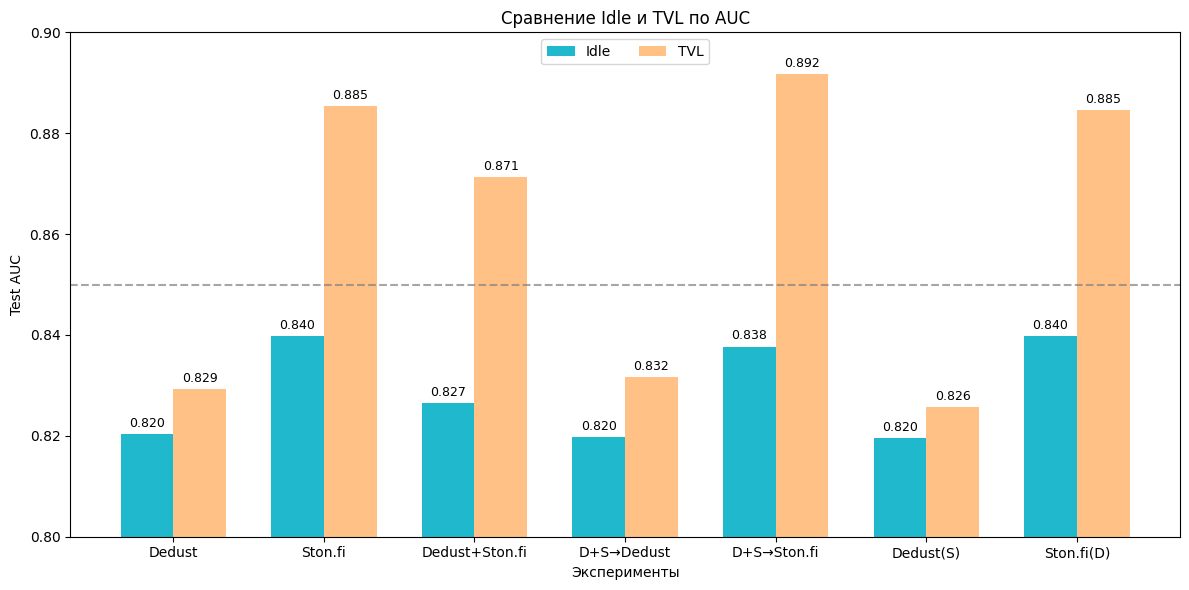

In [2]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

# Создаём датафрейм
data = {
    "experiment": [
        "Dedust", "Ston.fi", "Dedust+Ston.fi", "D+S→Dedust", "D+S→Ston.fi", 
        "Dedust(S)", "Ston.fi(D)", "Dedust", "Ston.fi", "Dedust+Ston.fi", 
        "D+S→Dedust", "D+S→Ston.fi", "Dedust(S)", "Ston.fi(D)"
    ],
    "approach": [
        "Idle", "Idle", "Idle", "Idle", "Idle", "Idle", "Idle",
        "TVL", "TVL", "TVL", "TVL", "TVL", "TVL", "TVL"
    ],
    "test_auc": [
        0.8203, 0.8397, 0.8265, 0.8198, 0.8377, 0.8196, 0.8397,
        0.8293, 0.8853, 0.8713, 0.8317, 0.8918, 0.8257, 0.8846
    ]
}
df = pd.DataFrame(data)

# Порядок экспериментов
experiments = ["Dedust", "Ston.fi", "Dedust+Ston.fi", "D+S→Dedust", "D+S→Ston.fi", "Dedust(S)", "Ston.fi(D)"]

# Подготовка данных для группового графика
idle_data = df[df['approach'] == 'Idle'].set_index('experiment').reindex(experiments)
tvl_data = df[df['approach'] == 'TVL'].set_index('experiment').reindex(experiments)

# Построение графика
fig, ax = plt.subplots(figsize=(12, 6))

bar_width = 0.35
indices = np.arange(len(experiments))

# Столбцы для Idle
bars_idle = ax.bar(indices - bar_width/2, idle_data['test_auc'], bar_width, label='Idle', color='#1FB8CD')
# Столбцы для TVL
bars_tvl = ax.bar(indices + bar_width/2, tvl_data['test_auc'], bar_width, label='TVL', color='#FFC185')

# Добавление значений на столбцы
for bars in [bars_idle, bars_tvl]:
    for bar in bars:
        height = bar.get_height()
        ax.annotate(f'{height:.3f}',
                    xy=(bar.get_x() + bar.get_width() / 2, height),
                    xytext=(0, 3),  # 3 точки вертикального смещения
                    textcoords="offset points",
                    ha='center', va='bottom', fontsize=9)

# Линия порога
ax.axhline(y=0.85, color='gray', linestyle='--', alpha=0.7)

# Подписи и заголовок
ax.set_xlabel('Эксперименты')
ax.set_ylabel('Test AUC')
ax.set_title('Сравнение Idle и TVL по AUC')
ax.set_xticks(indices)
ax.set_xticklabels(experiments)
ax.set_ylim(0.80, 0.9)
ax.legend(loc='upper center', bbox_to_anchor=(0.5, 1.0), ncol=2)

plt.tight_layout()
plt.savefig('auc_comparison_matplotlib.png')
plt.show()


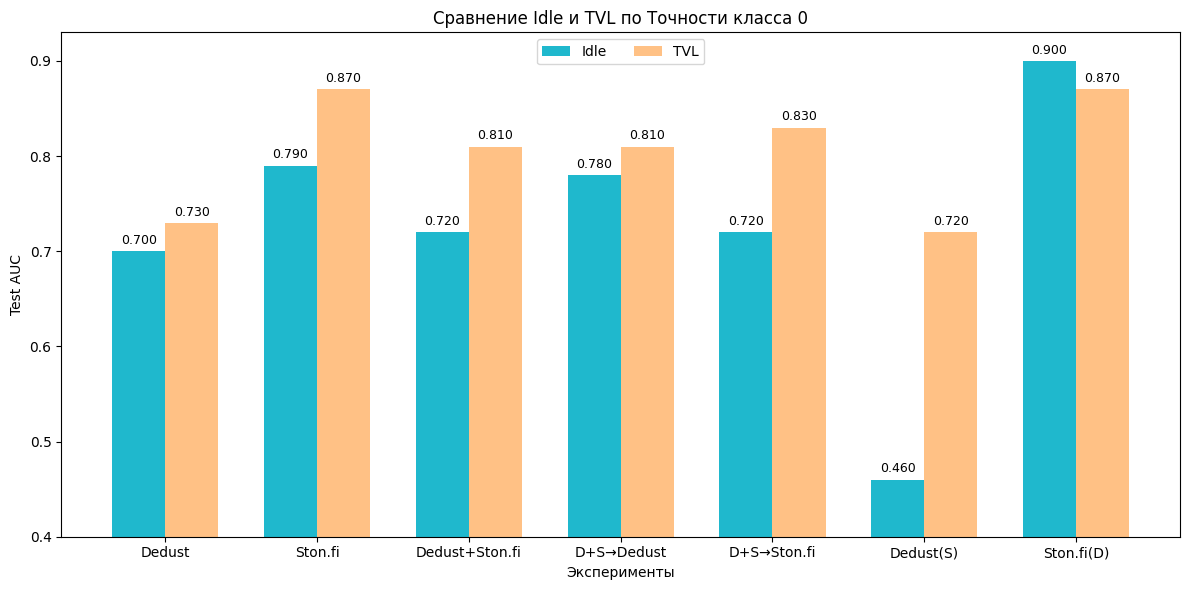

In [1]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

# Создаём датафрейм
data = {
    "experiment": [
        "Dedust", "Ston.fi", "Dedust+Ston.fi", "D+S→Dedust", "D+S→Ston.fi", 
        "Dedust(S)", "Ston.fi(D)", "Dedust", "Ston.fi", "Dedust+Ston.fi", 
        "D+S→Dedust", "D+S→Ston.fi", "Dedust(S)", "Ston.fi(D)"
    ],
    "approach": [
        "Idle", "Idle", "Idle", "Idle", "Idle", "Idle", "Idle",
        "TVL", "TVL", "TVL", "TVL", "TVL", "TVL", "TVL"
    ],
    "test_precision_0": [
    0.70,
    0.79,
    0.72,
    0.78,
    0.72,
    0.46,
    0.9,

    0.73,
    0.87,
    0.81,
    0.81,
    0.83,
    0.72,
    0.87,
    ]
}
df = pd.DataFrame(data)

# Порядок экспериментов
experiments = ["Dedust", "Ston.fi", "Dedust+Ston.fi", "D+S→Dedust", "D+S→Ston.fi", "Dedust(S)", "Ston.fi(D)"]

# Подготовка данных для группового графика
idle_data = df[df['approach'] == 'Idle'].set_index('experiment').reindex(experiments)
tvl_data = df[df['approach'] == 'TVL'].set_index('experiment').reindex(experiments)

# Построение графика
fig, ax = plt.subplots(figsize=(12, 6))

bar_width = 0.35
indices = np.arange(len(experiments))

# Столбцы для Idle
bars_idle = ax.bar(indices - bar_width/2, idle_data['test_precision_0'], bar_width, label='Idle', color='#1FB8CD')
# Столбцы для TVL
bars_tvl = ax.bar(indices + bar_width/2, tvl_data['test_precision_0'], bar_width, label='TVL', color='#FFC185')

# Добавление значений на столбцы
for bars in [bars_idle, bars_tvl]:
    for bar in bars:
        height = bar.get_height()
        ax.annotate(f'{height:.3f}',
                    xy=(bar.get_x() + bar.get_width() / 2, height),
                    xytext=(0, 3),  # 3 точки вертикального смещения
                    textcoords="offset points",
                    ha='center', va='bottom', fontsize=9)

# Линия порога
# ax.axhline(y=0.85, color='gray', linestyle='--', alpha=0.7)

# Подписи и заголовок
ax.set_xlabel('Эксперименты')
ax.set_ylabel('Test AUC')
ax.set_title('Сравнение Idle и TVL по Точности класса 0')
ax.set_xticks(indices)
ax.set_xticklabels(experiments)
ax.set_ylim(0.40, 0.93)
ax.legend(loc='upper center', bbox_to_anchor=(0.50, 1.0), ncol=2)

plt.tight_layout()
plt.savefig('precision_0_comparison_matplotlib.png')
plt.show()
